# Daniel Peña Fonseca

Use of LLMs (ChatGPT and Claude Sonet 4.6) for this exercise:

- Exercise 3.1 and Exercise 3.3: For Exercise 3.1, it was useful to notice the tab separating the label from the sentence in the data. For Exercise 3.3, it was mainly used for optimizing the code (since originally it was noticeably slower), particularly with the function train_epoch_vectorised. It was also used for understanding how the vectorizer works: CountVectorizer, .fit_transform, .transform. For the test evaluation, it was used to make the code cleaner.

- Exercise 3.2: Although it was useful for creating the function 'tokenize', it was not particularly helpful for the rest of the exercise.

- Exercise 3.4: It was used for the plot commands, and it was really helpful with the list comprehension to filter what ngrams from the sentence studied were inside and which ones were outside the training vocabulary.

- Exercise 3.5: For part A, it was not used, since that part was simply copied from the exercise 3.3. For part B, however, it was useful for using .vocabulary_ with the vectorizer, and for the generation of the combined vocabulary using sets, since I had never worked with them. Finally, it was helpful for the mask generation: in_base[unified_vocab[ng] + 1] = True; and for combining the masks to determine what the value of each w_c whould be, depending on whether the n-gram was in both the base and in the extended set, or just in one of them: w_c = np.where(...).

- Exercise 3.6: For generating the output, it was used for the function 'coverage'. For the plot, it was as helpful as it was for exercise 3.4 (it made the plot creation faster).

In [1]:
%pip install -q scikit-learn scipy transformers peft datasets torch

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Exercise 3.1 and 3.3
import numpy as np
import json
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score
import scipy.sparse as sp

# Exercise 3.2

import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset

# Exercise 3.1 and Exercise 3.3

For Exercise 3.1. we simply load the data taking into account that at the beginning, we have the label indicating the sentece classification.

For Exercise 3.3, we have to take multiple steps.
- First, we need to define how the perceptron will classify. The perceptron will perform a simple operation:
$$
y=w_0 + \sum_{i=1}^{M}w_ix_i
$$

Where $w_0$ is the bias, $x_i$ are the instances of each of the $M$ n-grams, and $w_i$ are the weights associated to each of the n-grams. However, this operation gives a real value, and we need a classification of 0 or 1. Therefore, if $y>0$, we classify as 1 (positive); otherwise, we classify as negative. 
- Next, we define how a training epoch works. After initially defining a simple but extremely slow approach, a more optimized way was chosen vectorizing with the function train_epoch_vectorised. Note that, to update the weights; i.e. train the model, we use the expression:
$$
w_j \leftarrow w_j + \eta(\gamma_i - c_i) x_{i,j}, \text{  } j=1, ..., M
$$
- Once we have defined what values of $n_{max}$ we want to study, we will analyze for each case, what is the most convenient value of $c_{min}$; i.e. which one yields the highest accuracy. For this matter, we first define vectorizer as indicated in the lectures, use vectorizer.fit_transform to the training data, since we want to transform the training data into ngrams and learn the vocabulary; and use vectorizer.transform for the validation set, since in that case we only want to transform the data into ngrams. After this, we just have to go over the epochs:
- The loop over the epochs imply: using the weights, we compute the predictions for the training set; and with these results we update the weights. With these new weights, we study how the model predicts for the validation set and compute the accuracy over the validation set. Then we repeat the process (loop)
- After the epochs are completed for the different values of $c_{min}$ for a certain value of $n_{max}$, we see which one yields the maximum validation accuracy and at which training epoch, since we want to keep the best performing model.
- Thus, for each value of $n_{max}$, we get the $c_{min}$ for which the lowest validation accuracy is obtained, this validation accuracy value, at what epoch it occured, and the model (weights).


Functions that we use:

vectorizer.fit_transform(train_texts).astype(float) has the shape: (number of rows in training set, vocabulary size), and does the following:

1. Fit: It learns the vocabulary from the training set (builds the dictionary using min_df=c_min in the data set).
2. Transform: It converts each text into a row of n-gram counts using the vocabulary learned from the training set.

vectorizer.transform is what we will apply to the validation and the test set since we do not want to fit these data sets. Here, we just separate into n-grams using the vocabulary learned from the training set.


In [2]:
# We load the data
def load_data(filepath):
    "Each line has the shape: label<TAB> and then space-separated tokens"
    labels, raw_texts = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            tab_idx = line.index('\t')
            labels.append(int(line[:tab_idx]))
            raw_texts.append(line[tab_idx + 1:])   # keep as single string for CountVectorizer
    return np.array(labels), raw_texts


train_labels, train_texts = load_data('Assignment_3/ReviewBaseTraining.txt')
val_labels,   val_texts   = load_data('Assignment_3/ReviewBaseValidation.txt')
test_labels,  test_texts  = load_data('Assignment_3/ReviewBaseTest.txt')


# We compute the perceptron prediction vectorized to improve efficiency
def perceptron_predict(X, weights):
    """
    This function computes the perceptron prediction
    """
    scores = X.dot(weights[1:]) + weights[0]
    return (scores > 0).astype(int) # Array of prediction with 1s and 0s


def train_epoch_vectorised(X_train, y_train, weights, learning_rate):
    "This function performs one epoch (weight update) optimized with sparse matrices to make it faster"
    n = X_train.shape[0]
    
    X_csr = X_train.tocsr() # We optimize to make computations faster. We convert to CSR for fast row slicing
    for i in range(n):
        xi        = X_csr.getrow(i)                         # Each row contains x_1,x_2, ..., x_{n_features}. This is what we need for the perceptron output
        score     = xi.dot(weights[1:]).item() + weights[0] # perceptron output
        predicted = 1 if score > 0 else 0
        delta     = learning_rate * (y_train[i] - predicted)
        if delta != 0:
            weights[0]  += delta                          # The first weight is not associated to any feature. In this case we use new_weight = past_weight + delta
            weights[1:] += delta * xi.toarray().ravel()   # xi.toarray().ravel() converts the sparse row to a flat array so I can do the addition.
    return weights





In [3]:

learning_rate    = 1e-3
number_of_epochs = 30
n_max_list       = [1, 2, 3]
c_min_list       = [1, 3, 10, 100]

best_c_mins        = []
best_epochs_per_n  = []
best_weights_per_n = []
best_vectorizers   = []

for n_max in n_max_list:
    print(' ')
    highest_val_accs  = []
    best_epochs_list  = []
    best_weights_list = []
    best_vecs_list    = []

    for c_min in c_min_list:
        print(f"  n_max={n_max}, c_min={c_min} ...")
        
        vectorizer = CountVectorizer(
            ngram_range=(1, n_max), # extract all n-grams from size 1 up to n_max
            min_df=c_min,           # only keep those appearing more than c_min times
            analyzer='word',        # characters are not considered
            token_pattern=r'\S+',   # defining what counts as token (a token is formed by one or more non-whitespace characters)
        )
        # We transform as said in the lecture
        X_train = vectorizer.fit_transform(train_texts).astype(float)
        X_val   = vectorizer.transform(val_texts).astype(float)

        n_features = X_train.shape[1]
        #print(f"    Vocabulary size: {n_features}")

        # The number of weights will be the number of features + 1, since the formula is w_0+\sum_i w_kx_k, where w_k is a weight and x_k the number of instances of k in the text under study.
        weights            = np.zeros(n_features + 1)
        best_epoch_weights = weights.copy()
        val_acc_list       = []

        for epoch in range(number_of_epochs):
            weights = train_epoch_vectorised(X_train, train_labels, weights, learning_rate) # We update weights using the training data

            preds   = perceptron_predict(X_val, weights) # Compute prediction for validation set using new weights
            val_acc = accuracy_score(val_labels, preds)  # Compute validation accuracy checking the amount of times the model predicted correctly
            val_acc_list.append(val_acc)

            if val_acc >= max(val_acc_list):
                best_epoch_weights = weights.copy()

            #print(f"    Epoch {epoch:2d} | val_acc={val_acc:.4f}")#, flush=True)

        # We want to store the epoch at which the validation accuracy is maximum. And the value
        max_val_acc = max(val_acc_list)
        best_epoch  = val_acc_list.index(max_val_acc)

        print(f"    Vocabulary size: {n_features}   |    Maximum validation accuracy: {max_val_acc:.4f}")

        highest_val_accs.append(max_val_acc)
        best_epochs_list.append(best_epoch)
        best_weights_list.append(best_epoch_weights)
        best_vecs_list.append(vectorizer)

    # For each n_max, we only keep the information (Best epoch, maximum accuracy and weights) for the most useful c_min
    best_idx   = int(np.argmax(highest_val_accs))
    best_c_min = c_min_list[best_idx]

    best_c_mins.append(best_c_min)
    best_epochs_per_n.append(best_epochs_list[best_idx])
    best_weights_per_n.append(best_weights_list[best_idx])
    best_vectorizers.append(best_vecs_list[best_idx]) # For each n_max we keep the vectorizer for the best performing c_min

    print(f"\n  Therefore: n_max={n_max}: best c_min={best_c_min}, " f"best_epoch={best_epochs_list[best_idx]}, " f"val_acc={highest_val_accs[best_idx]:.4f}\n")



 
  n_max=1, c_min=1 ...
    Vocabulary size: 50113   |    Maximum validation accuracy: 0.8530
  n_max=1, c_min=3 ...
    Vocabulary size: 23265   |    Maximum validation accuracy: 0.8552
  n_max=1, c_min=10 ...
    Vocabulary size: 10756   |    Maximum validation accuracy: 0.8502
  n_max=1, c_min=100 ...
    Vocabulary size: 1836   |    Maximum validation accuracy: 0.8522

  Therefore: n_max=1: best c_min=3, best_epoch=11, val_acc=0.8552

 
  n_max=2, c_min=1 ...
    Vocabulary size: 701051   |    Maximum validation accuracy: 0.8684
  n_max=2, c_min=3 ...
    Vocabulary size: 139146   |    Maximum validation accuracy: 0.8656
  n_max=2, c_min=10 ...
    Vocabulary size: 41471   |    Maximum validation accuracy: 0.8642
  n_max=2, c_min=100 ...
    Vocabulary size: 4307   |    Maximum validation accuracy: 0.8580

  Therefore: n_max=2: best c_min=1, best_epoch=28, val_acc=0.8684

 
  n_max=3, c_min=1 ...
    Vocabulary size: 2359114   |    Maximum validation accuracy: 0.8692
  n_max=3, c_

## Test evaluation

Now, using the best model (weights) for each value of $n_{max}$, we compute the test accuracy the same way we computed the validation accuracy for Exercise 3.3.:
- We transform the test set to ngrams using the training set's vocabulary, we predict using the best model's weights, and we compute the accuracy using an imported function accuracy_score.

In [5]:

# Test evaluation
print('Best results: ')

results = []

for i, n_max in enumerate(n_max_list):

    # We recuperate the best vectorizer and best weights for each n_max
    vectorizer = best_vectorizers[i]
    weights    = best_weights_per_n[i]

    # Transform as indicated in lecture
    X_val  = vectorizer.transform(val_texts).astype(float)
    X_test = vectorizer.transform(test_texts).astype(float)

    # Score
    val_acc  = accuracy_score(val_labels, perceptron_predict(X_val, weights))
    test_acc = accuracy_score(test_labels, perceptron_predict(X_test, weights))

    # For each n_max, best_c_min, we save the epoch at which the best model was obtained, along with the validation accuracy and test accuracy
    results.append({
        'n_max':      n_max,
        'c_min':      best_c_mins[i],
        'best_epoch': best_epochs_per_n[i],
        'val_acc':    round(val_acc,  4),
        'test_acc':   round(test_acc, 4),
    })

    print(f"n_max={n_max} | c_min={best_c_mins[i]} | epoch={best_epochs_per_n[i]} "
          f"| val={val_acc:.4f} | test={test_acc:.4f}")

"""# We save them just in case (although in this case it does not take a long time to run the code)
with open('Assignment_3/final_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Saved in final_results.json")"""

Best results: 
n_max=1 | c_min=3 | epoch=11 | val=0.8552 | test=0.8670
n_max=2 | c_min=1 | epoch=28 | val=0.8684 | test=0.8848
n_max=3 | c_min=1 | epoch=17 | val=0.8692 | test=0.8804


'# We save them just in case (although in this case it does not take a long time to run the code)\nwith open(\'Exercise_3/final_results.json\', \'w\') as f:\n    json.dump(results, f, indent=2)\nprint("Saved in final_results.json")'

# Exercise 3.2

In this case, we want to use the model Deberta-v3-small to identify the sentiment of the sentences. In order to determine what are the best performing parameters (learning rate, rank, ...), we have to try different values (hyperparameter sweep), until we find suitable parameters. Those used in the following code were chosen since they yield the best results out of all the parameter combinations that were tried.

Since Deberta has a huge amount of parameters, and fine tuning them has a high computational cost, we use Lora, and fine tune only a small fraction of them.

In this case, the obtained accuracy is higher than the ones obtained for the n-gram model. This probably occurs because the black box model is trained over massive amounts of text and therefore has a huge advantage over the interpretable model; whose knowledge of the language is limited to the training set.

In [9]:
# huggingface datasets, so that the trainer understands
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels.tolist()})
val_dataset   = Dataset.from_dict({'text': val_texts,   'label': val_labels.tolist()})
test_dataset  = Dataset.from_dict({'text': test_texts,  'label': test_labels.tolist()})

# Tokenize. This tokenizer splits the data into tokens the model was trained on
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")

def tokenize(batch):
    return tokenizer(
        batch['text'], # raw text strings
        truncation=True, # if a text is longer than max_length, we cut it
        max_length=512, # maximum tokens per sample
        padding='max_length', # if we have shorter texts, we pad
    )

# running over every sample in the dataset
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

# .from_pretrained loads pretrained deberta weights
# num_labels 2 because we have 0 or 1
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
)

# Lora
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # classification
    r=16, # size of low rank matrices. higher value is more capacity, but more parameters
    lora_alpha=32, 
    lora_dropout=0.15, # we apply dropout to avoid overfitting
    target_modules=["query_proj", "value_proj"]
)
model = get_peft_model(model, lora_config) # adding lora
model.print_trainable_parameters() # We make sure we are training just some parameters

# now we measure the accuracy
def measure_accuracy(eval_prediction):
    scores, labels = eval_prediction
    predictions = np.argmax(scores, axis=-1) # class with highest score is the selected one
    accuracy = np.mean(predictions == labels) # how many times the prediction matches the actual label
    return {'accuracy': accuracy}

training_args = TrainingArguments(
    output_dir="Assignment_3/deberta-lora", # saving
    num_train_epochs=4,
    per_device_train_batch_size=16,
    eval_strategy="epoch", # we see the validatio after each epoch
    save_strategy="epoch", # we save checkpoint
    load_best_model_at_end=True, # we want to keep the best model (model at epoch with highest validation accuracy) when the training finishes
    metric_for_best_model="eval_accuracy", # the best model is the one with highest validation accuracy
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=measure_accuracy
)
# Training
trainer.train() # we run it

# Test set results
test_results = trainer.evaluate(test_dataset)
print("Test results:", test_results)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias       

trainable params: 296,450 || all params: 142,192,900 || trainable%: 0.2085


Epoch,Training Loss,Validation Loss,Accuracy
1,0.503703,0.234777,0.915800
2,0.222377,0.232663,0.923800
3,0.195100,0.216342,0.928000
4,0.182530,0.216020,0.929400


Test results: {'eval_loss': 0.17233815789222717, 'eval_accuracy': 0.941, 'eval_runtime': 67.131, 'eval_samples_per_second': 74.481, 'eval_steps_per_second': 9.31, 'epoch': 4.0}


# Exercise 3.4

In this case, we will study how the model 'understands' a certain sentence, and we repeat the process for different sentences. For this exercise, we fix $n_{max}=3$, since all the figures for $n_{max}=1$, $n_{max}=2$ and $n_{max}=3$ will be presented in Exercise 3.6 to study how the coverage ratio changes with $n_{max}$. The way in which the model 'understands' a sentence; i.e. what the model uses to classify the sentence as positive or negative, are the weights of each n-gram. An n-gram with a positive weight contributes towards making the model classify the sentence as positive; while a negative weight contributes to a negative classification. With this visualization, we can understand why the model classifies each sentence the way it does (interpretability), and therefore see what the model is learning with the training data that we trained it with. 

For the sentences studied here, we can see that 'sweet' and 'funny' have positive weights, as expected, since 'sweet' and 'funny' are usually associated to a positive experience. However, the model associates the unigram 'minutes' with a negative classification.

Note: I chose sentences between 15 and 30 words because my loop could not find more than 1 word in the range 15-25.

Note that the coverage ratio has the following definition:
$$
\text{Coverage ratio}=\frac{\text{Number of distinct n-grams present in the text under study that were also in the training set}}{\text{Number of distinct n-grams present in the text under study}}
$$


n_max=3: Found 4 sentences for visualization.
  Overall test-set coverage ratio (n_max=3, c_min =1): 0.7587


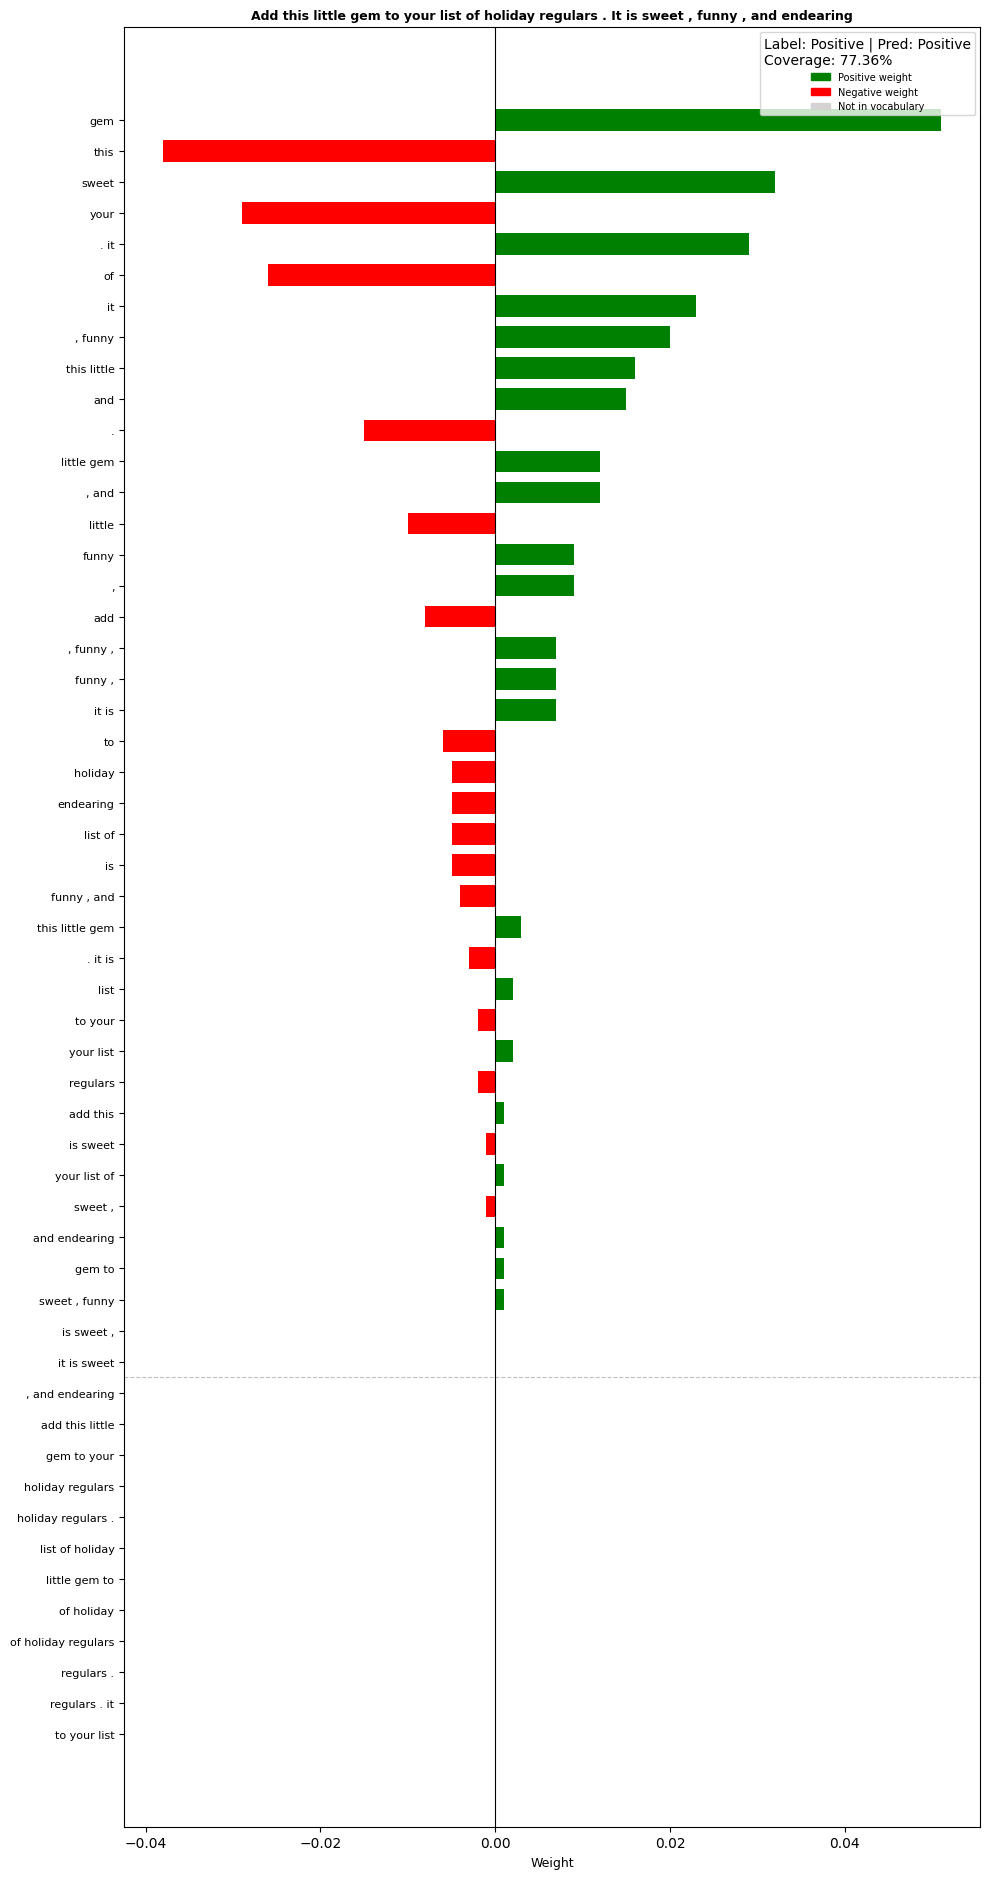

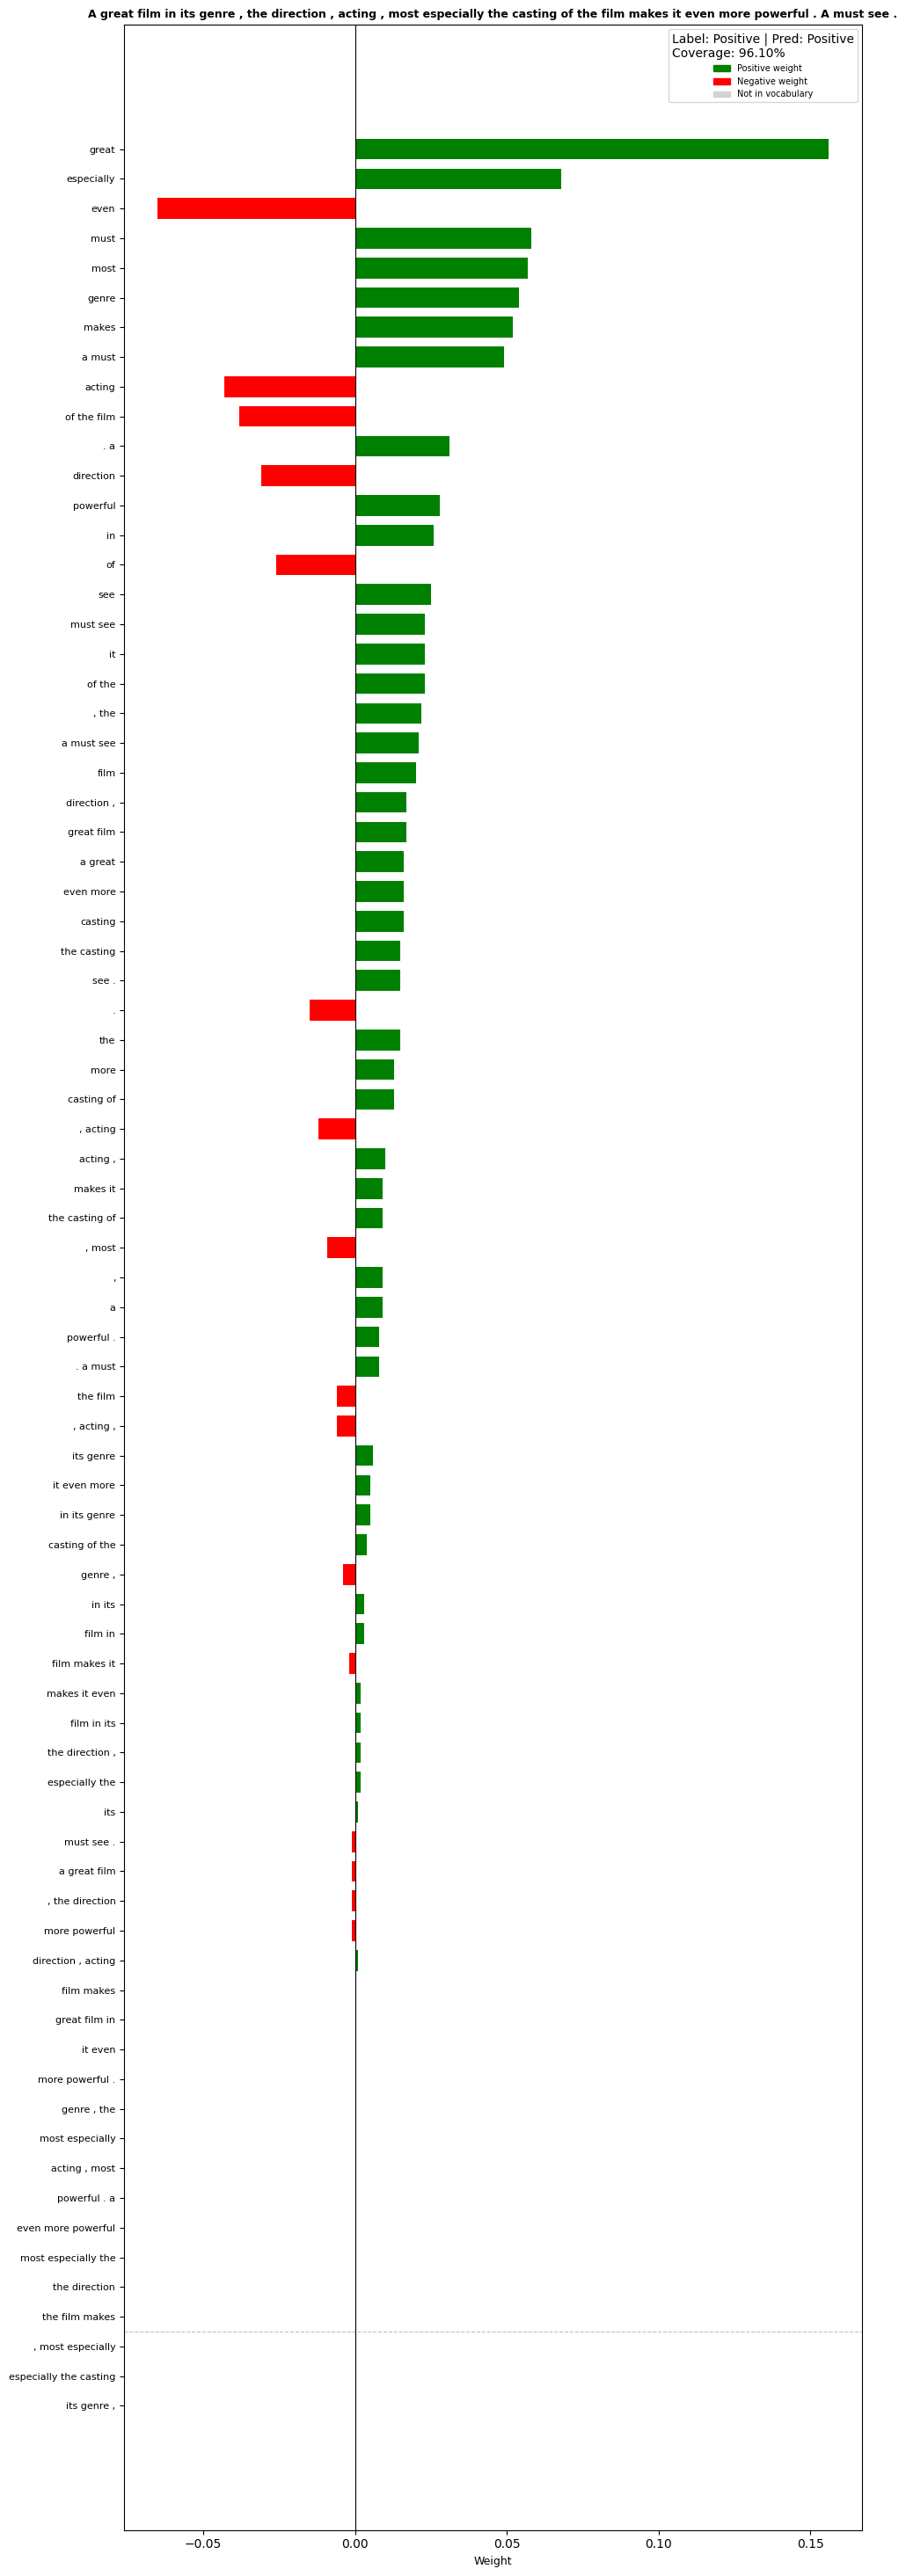

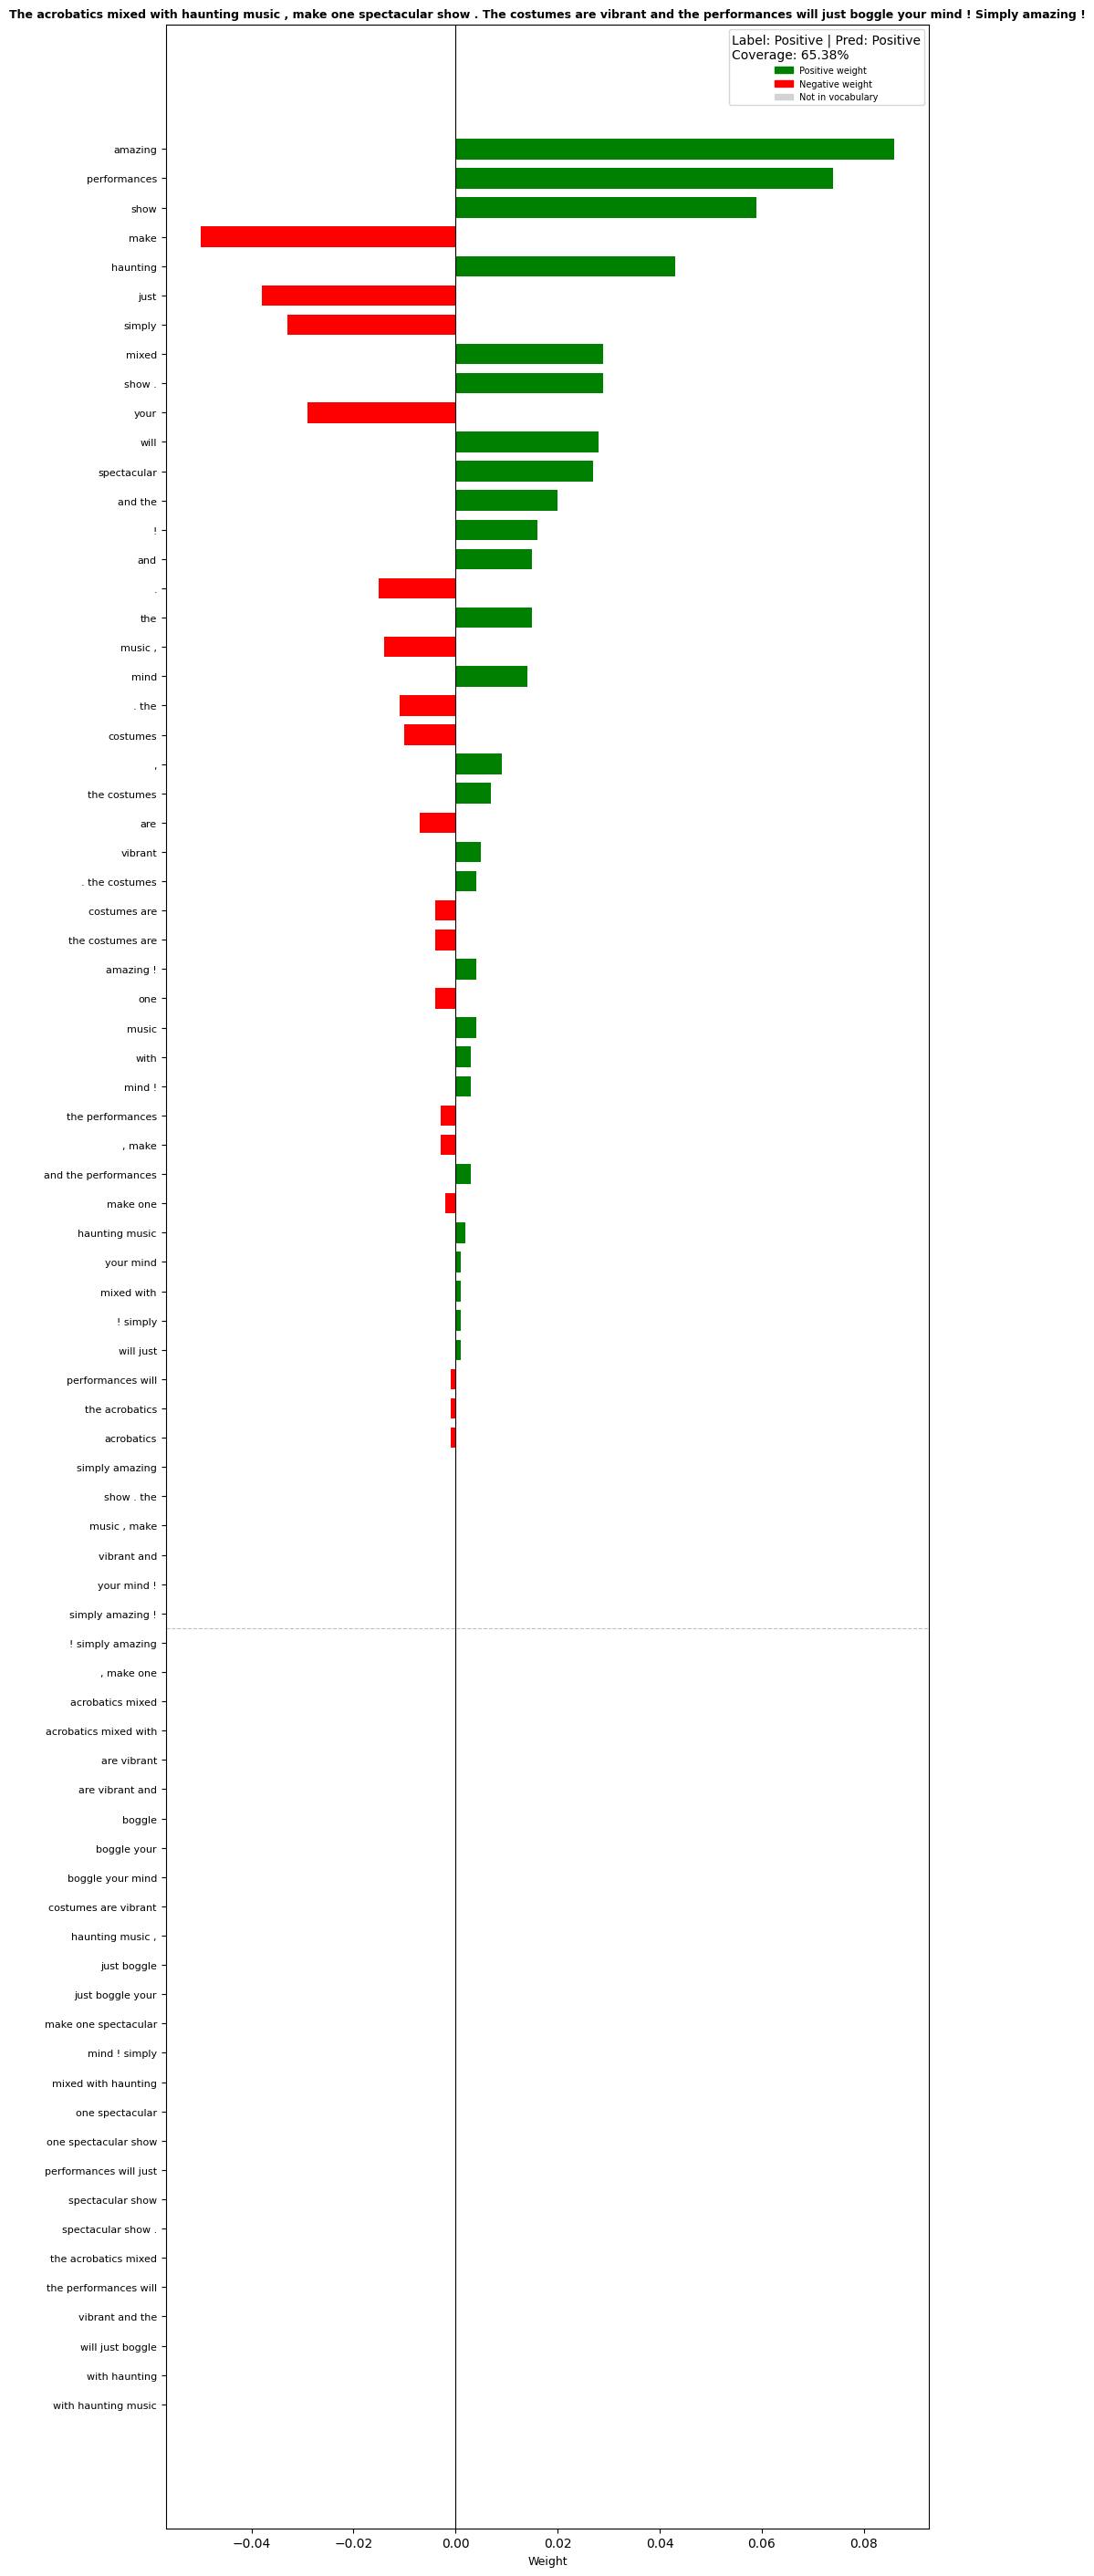

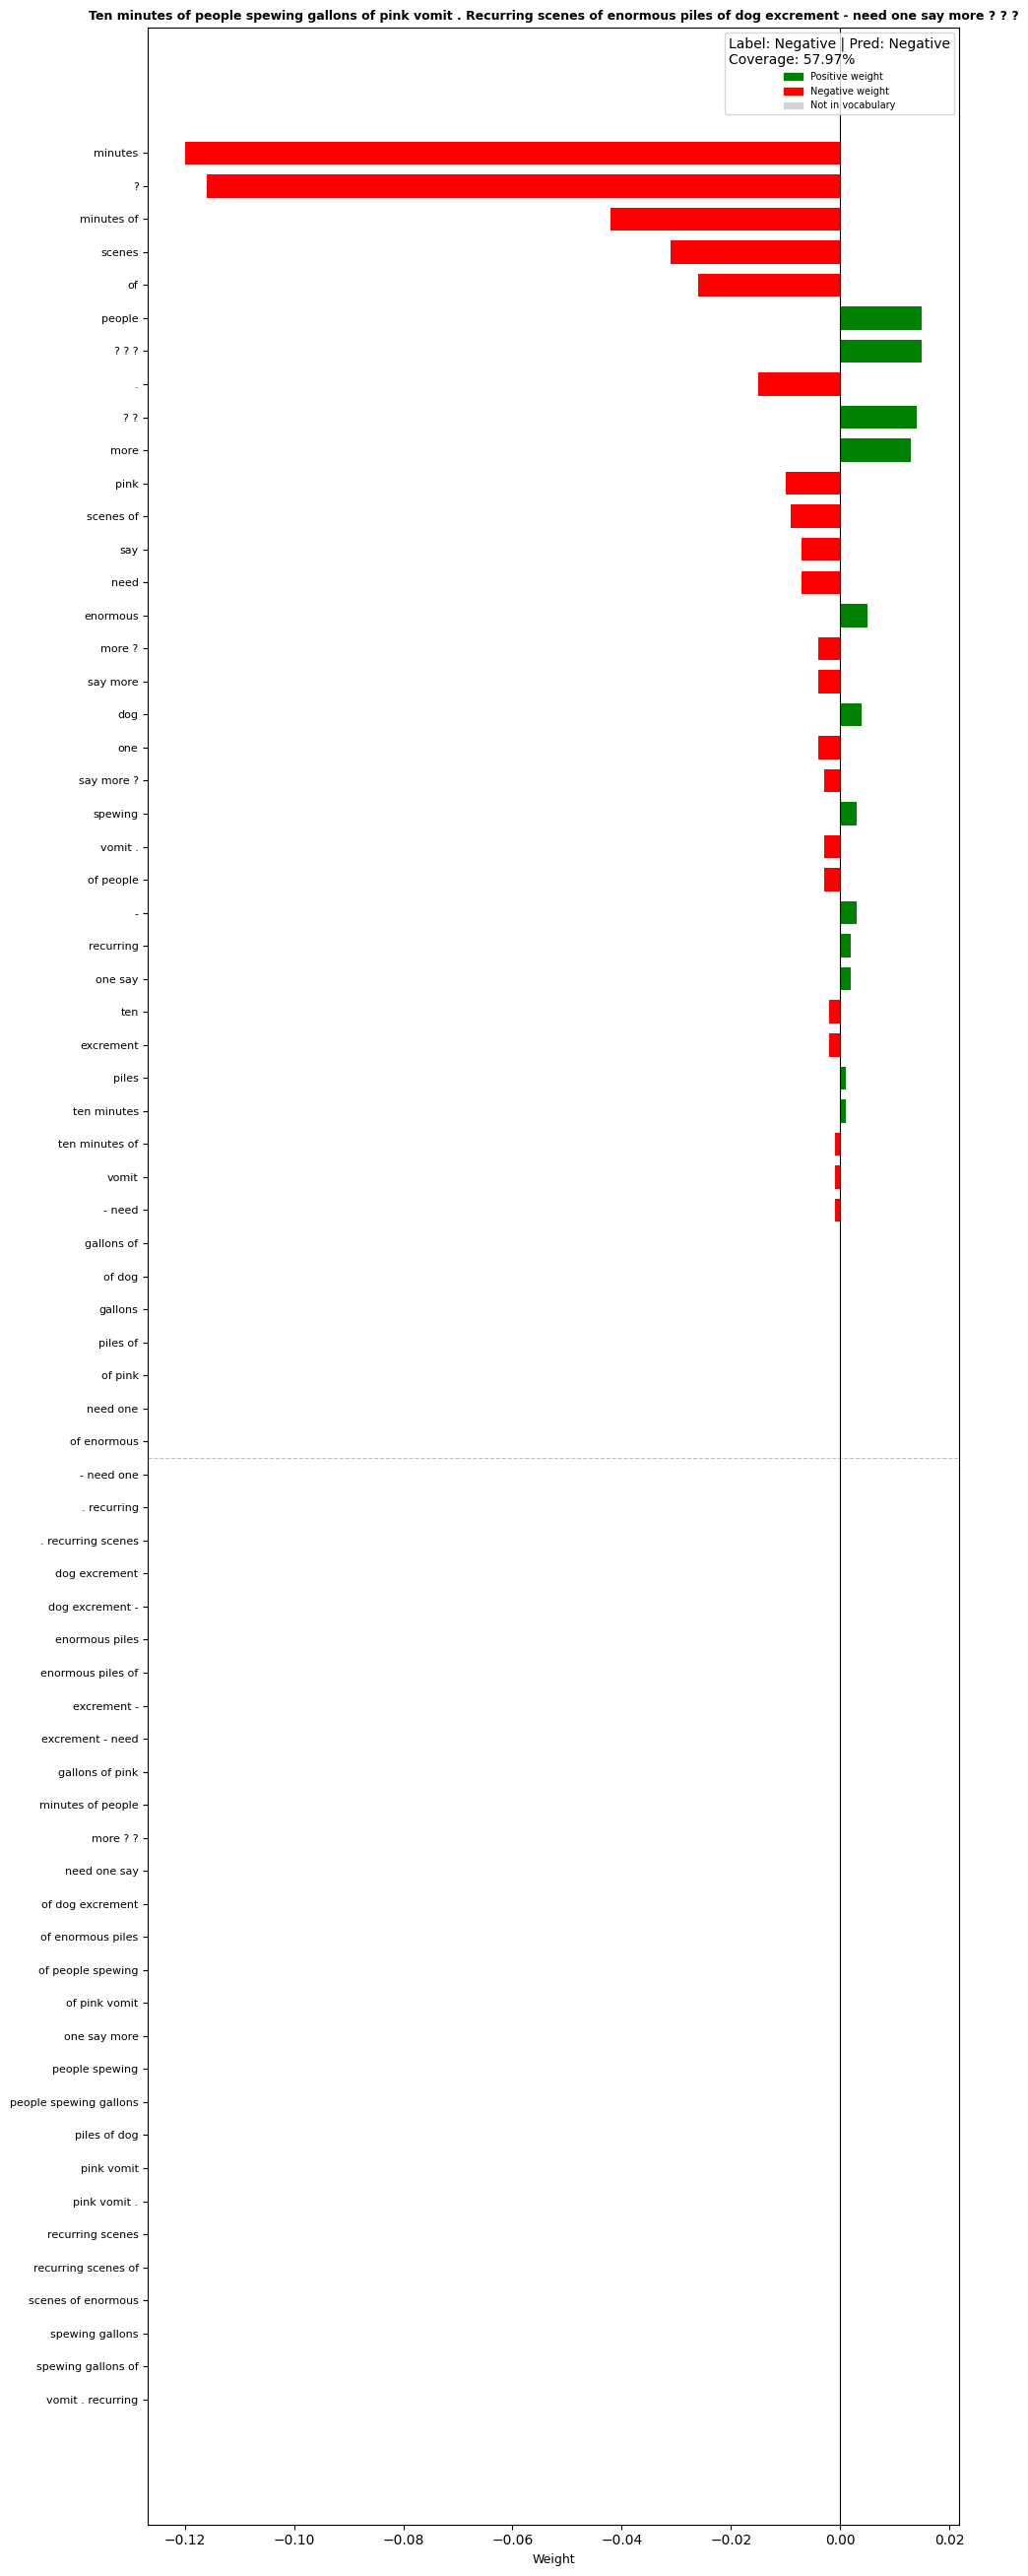

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_review_weights(sentence, true_label, vectorizer, weights, n_max, ax=None):
    "For a certain sentence, this function will indicate what are the weights associated to each of the n-grams present in the sentence."
    "This will be visualized with a bar graph"
    
    # We extract the vocabulary from the vectorizer, which was fitted over the training data
    vocab = vectorizer.vocabulary_  # {ngram: index}
    idx_to_ngram = {v: k for k, v in vocab.items()}

    # Since we defined n-grams as tokens separated by space characterss, we use the same logic here
    import re
    token_pattern = r'\S+'
    tokens = re.findall(token_pattern, sentence.lower())

    # Generate all n-grams (1 to n_max) present in this sentence
    sentence_ngrams = set()
    for n in range(1, n_max + 1):

        # the last element is tokens[len(tokens)-1]; therefore, if we look for unigrams, we would go until: tokens[len(tokens)-1]
        # if we look for bigrams we would go until tokens[len(tokens)-2]; trigrams: tokens[len(tokens)-3] ...
        # since range decreases one index on the last value, we go until range(len(tokens)-n+1) (+1 to compensate for the range limitation)
        for i in range(len(tokens) - n + 1):
            gram = ' '.join(tokens[i:i+n])
            sentence_ngrams.add(gram)

    
    # To the n-grams present in the vocabulary (present in the training set more than c_min times) we assign their weight
    # To the n-grams not present in the vocabulary, we will not assign weights
    in_vocab  = [(g, weights[vocab[g] + 1]) for g in sentence_ngrams if g in vocab]
    out_vocab = [g for g in sentence_ngrams if g not in vocab]

    
    # Visually, we want to see the most important n-grams at the beginning (highest abs(weight))
    in_vocab_sorted  = sorted(in_vocab, key=lambda x: abs(x[1]), reverse=True)
    out_vocab_sorted = sorted(out_vocab)

    # Coverage ratio (defined in Markdown)
    n_total    = len(sentence_ngrams)
    n_covered  = len(in_vocab)
    coverage   = n_covered / n_total if n_total > 0 else 0.0

    # Prediction
    X_sentence = vectorizer.transform([sentence]).astype(float)
    pred_label = int(perceptron_predict(X_sentence, weights)[0]) # class predicted by model
    pred_str   = 'Positive' if pred_label == 1 else 'Negative'
    true_str   = 'Positive' if true_label  == 1 else 'Negative'

    
    # I will plot all grams, whether they are part of my vocabulary or not
    all_grams   = [g for g, _ in in_vocab_sorted] + out_vocab_sorted
    all_weights = [w for _, w in in_vocab_sorted] + [0.0] * len(out_vocab_sorted)
    in_vocab_count = len(in_vocab_sorted)

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(6, len(all_grams) * 0.35)))

    y_pos  = np.arange(len(all_grams))
    colors = []
    for i, w in enumerate(all_weights):
        if i >= in_vocab_count:
            colors.append('lightgray') # If I do not have the n-gram in my vvocabulary -> no weight (no bar)
        elif w >= 0:
            colors.append('green') # green for positive
        else:
            colors.append('red') # red for negative

    
    # Visible (real) weights for the n-grams in the vocabulary, 0 weights for the n-grams out of my vocabulary
    bar_vals = all_weights[:in_vocab_count] + [0.0] * len(out_vocab_sorted)
    bars = ax.barh(y_pos, bar_vals, color=colors, edgecolor='none', height=0.7)

    # With a line, I separate the n-grams present in my vocabulary from those that are not
    if out_vocab_sorted and in_vocab_sorted:
        sep = in_vocab_count - 0.5 # separator between last inside-vocabulary ngram and first out-of-vocabulary ngram 
        ax.axhline(sep, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_grams, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Weight', fontsize=9)
    ax.set_title(sentence, fontsize=9, fontweight='bold', pad=6)

    # Legend
    green_patch = mpatches.Patch(color='green', label='Positive weight')
    red_patch   = mpatches.Patch(color='red', label='Negative weight')
    gray_patch  = mpatches.Patch(color='lightgray', label='Not in vocabulary')
    ax.legend(
        handles=[green_patch, red_patch, gray_patch],
        loc='upper right', fontsize=7,
        title=f'Label: {true_str} | Pred: {pred_str}\nCoverage: {coverage:.2%}',
        title_fontsize=10
    )

    ax.invert_yaxis() # highest abs(weight) at top
    return coverage

def run_visualization(n_max_idx, n_sentences=4):
    n_max      = n_max_list[n_max_idx]
    vectorizer = best_vectorizers[n_max_idx]
    weights    = best_weights_per_n[n_max_idx]

    # sentences between 15 and 30 words
    sentences_under_study = []
    labels_under_study    = []
    for i, text in enumerate(test_texts):
        word_count = len(text.split())
        if 15 <= word_count <= 30:
            sentences_under_study.append(text)
            labels_under_study.append(test_labels[i])
        if len(sentences_under_study) == n_sentences:
            break

    print(f"\nn_max={n_max}: Found {len(sentences_under_study)} sentences for visualization.")

    # Coverage ratio of full test set. It is useful to see what is the ratio of the full text next to that of 
    # the sentence under study
    import re
    token_pattern = r'\S+'
    # Vocabulary
    vocab = vectorizer.vocabulary_

    total_ngrams   = 0 # denominator of coverage ratio (see markdown for definition)
    covered_ngrams = 0 # numerator of coverage ratio
    for text in test_texts:
        tokens = re.findall(token_pattern, text.lower()) # important to specify lower.() to be consistent with vectorizer
        for n in range(1, n_max + 1):
            for i in range(len(tokens) - n + 1):
                gram = ' '.join(tokens[i:i+n])
                total_ngrams += 1
                if gram in vocab:
                    covered_ngrams += 1

    overall_coverage = covered_ngrams / total_ngrams if total_ngrams > 0 else 0.0
    print(f"  Overall test-set coverage ratio (n_max={n_max}, c_min ={best_c_mins[2]}): {overall_coverage:.4f}")

    # One figure per sentence
    coverages = []
    # We count how many ngrams are in the sentence, this will help us decide whether to make the plot bigger or smaller
    # We add 1 for each valid ngram. for n in range() takes into account all possible ns. The second for takes into account
    # all possible starts for counting ngrams.
    for idx, (sentence, label) in enumerate(zip(sentences_under_study, labels_under_study)):
        n_grams_in_sentence = sum(
            1 for n in range(1, n_max + 1)
            for i in range(len(re.findall(r'\S+', sentence.lower())) - n + 1)
        )
        fig, ax = plt.subplots(figsize=(10, max(6, n_grams_in_sentence * 0.35)))

        cov = visualize_review_weights(sentence, label, vectorizer, weights, n_max, ax=ax)
        coverages.append(cov) # list of coverage ratios
        fig.tight_layout()
        plt.show()

    return overall_coverage

# Here i just present for n_max=3. The rest will be plotted in the last exercise
all_coverages = {}
idx=2
cov = run_visualization(idx, n_sentences=4)
all_coverages[n_max_list[idx]] = cov

# Exercise 3.5

## Part A

For the first part of this exercise, the procedure is the same as in exercise 3.1 and 3.3, although now we use the extended set. By training our interpretable model over a larger data set, we will be able to make a less unfair comparison between the black-box model and our linear perceptron.

Therefore, for $n_{max} = 1$, $n_{max} = 2$, and $n_{max} = 3$, we will try different values of $c_{min}$, and fit our models to the training data. The model for which the highest validation accuracy is obtained will determine what is the optimal value of $c_{min}$ for each value of $n_{max}$. The best model for each $n_{max}$ will be kept for the next exercise (combining weights).

Note: The following cell, at least in my computer, took 37 minutes to run.

In [14]:

# Extended dataset (we copy paste from before, since the procedure to obtain the best c_min for each n_max is the same as with the base set)
train_labels_new, train_texts_new = load_data('Assignment_3/ReviewExtendedTraining.txt')
val_labels_new,   val_texts_new   = load_data('Assignment_3/ReviewExtendedValidation.txt')

learning_rate_new    = 1e-3
number_of_epochs_new = 30

best_c_mins_new        = []
best_epochs_per_n_new  = []
best_weights_per_n_new = []
best_vectorizers_new   = []

print('Extended set: ')
for n_max in n_max_list:
    print(' ')
    highest_val_accs_new  = []
    best_epochs_list_new  = []
    best_weights_list_new = []
    best_vecs_list_new    = []

    for c_min in c_min_list:
        print(f" n_max={n_max}, c_min={c_min} ...")

        vectorizer_new = CountVectorizer(
            ngram_range=(1, n_max),
            min_df=c_min,
            analyzer='word',
            token_pattern=r'\S+',
        )
        X_train_new = vectorizer_new.fit_transform(train_texts_new).astype(float)
        X_val_new   = vectorizer_new.transform(val_texts_new).astype(float)

        n_features_new = X_train_new.shape[1]

        weights_new            = np.zeros(n_features_new + 1)
        best_epoch_weights_new = weights_new.copy()
        val_acc_list_new       = []

        for epoch in range(number_of_epochs_new):
            weights_new = train_epoch_vectorised(X_train_new, train_labels_new, weights_new, learning_rate_new)

            preds_new   = perceptron_predict(X_val_new, weights_new)
            val_acc_new = accuracy_score(val_labels_new, preds_new)
            val_acc_list_new.append(val_acc_new)

            if val_acc_new >= max(val_acc_list_new):
                best_epoch_weights_new = weights_new.copy()

        max_val_acc_new = max(val_acc_list_new)
        best_epoch_new  = val_acc_list_new.index(max_val_acc_new)

        print(f"    Vocabulary size: {n_features_new}   |    Maximum validation accuracy: {max_val_acc_new:.4f}")

        highest_val_accs_new.append(max_val_acc_new)
        best_epochs_list_new.append(best_epoch_new)
        best_weights_list_new.append(best_epoch_weights_new)
        best_vecs_list_new.append(vectorizer_new)

    best_idx_new   = int(np.argmax(highest_val_accs_new))
    best_c_min_new = c_min_list[best_idx_new]

    best_c_mins_new.append(best_c_min_new)
    best_epochs_per_n_new.append(best_epochs_list_new[best_idx_new])
    best_weights_per_n_new.append(best_weights_list_new[best_idx_new])
    best_vectorizers_new.append(best_vecs_list_new[best_idx_new])

    print(f"\n n_max={n_max}: best c_min={best_c_min_new}, "
          f"best_epoch={best_epochs_list_new[best_idx_new]}, "
          f"val_acc={highest_val_accs_new[best_idx_new]:.4f}\n")

Extended set: 
 
 n_max=1, c_min=1 ...
    Vocabulary size: 96551   |    Maximum validation accuracy: 0.8511
 n_max=1, c_min=3 ...
    Vocabulary size: 30496   |    Maximum validation accuracy: 0.8536
 n_max=1, c_min=10 ...
    Vocabulary size: 13735   |    Maximum validation accuracy: 0.8503
 n_max=1, c_min=100 ...
    Vocabulary size: 2934   |    Maximum validation accuracy: 0.8410

 n_max=1: best c_min=3, best_epoch=19, val_acc=0.8536

 
 n_max=2, c_min=1 ...
    Vocabulary size: 1039356   |    Maximum validation accuracy: 0.8767
 n_max=2, c_min=3 ...
    Vocabulary size: 200624   |    Maximum validation accuracy: 0.8753
 n_max=2, c_min=10 ...
    Vocabulary size: 64973   |    Maximum validation accuracy: 0.8760
 n_max=2, c_min=100 ...
    Vocabulary size: 8443   |    Maximum validation accuracy: 0.8571

 n_max=2: best c_min=1, best_epoch=13, val_acc=0.8767

 
 n_max=3, c_min=1 ...
    Vocabulary size: 3522550   |    Maximum validation accuracy: 0.8785
 n_max=3, c_min=3 ...
    Voca

## Part B

Now that we have obtained our best values of $c_{min}$ for each value of $n_{max}$, we will average the weights of the extended model using the weights from the base model. For an n-gram that is present both in the base training set and in the extended training set, the combined weight will be 
$$
    w_c = \alpha w_b + (1-\alpha)w_e
$$
However, if the n-gram is only present in the base training set: $w_c=w_b$; and if the n-gram is only present in the extended training set: $w_c = w_e$.
In order to manage these conditions, every time an ngram is found in one data set, one could loop over all the ngrams in the other data set to find out if the ngram is also present in the other data set; however, this procedure is extremely slow. A more optimized option is creating a combined dictionary, containing both the vocabulary of the base training set and of the extended training set. Using masks as described below in the code, the procedure is done faster than with a loop system.

Once the procedure has been defined, we analyze for what value of $\alpha$ the best results are obtained by trying out different values (0.1, 0.2, ..., 0.9) and we keep, for each case of $n_{max}$, the $\alpha$ for which the validation accuracy is the highest.

In [15]:


alpha_list = np.arange(0.1, 1.0, 0.1)  # 0.1, 0.2, ..., 0.9

combined_results = []
best_weights_combined = []
best_vectorizers_combined = []

for i, n_max in enumerate(n_max_list):

    # From base data
    vec_b     = best_vectorizers[i]          
    weights_b = best_weights_per_n[i] # [bias, w1, ..., w_vocab_size]
    vocab_b   = vec_b.vocabulary_            

    # From extended data
    vec_e     = best_vectorizers_new[i]
    weights_e = best_weights_per_n_new[i] # [bias, w1, ..., w_vocab_size]
    vocab_e   = vec_e.vocabulary_

    # Since we want to average the weights, we have to create a combined vocabulary.
    all_ngrams = set(vocab_b.keys()) | set(vocab_e.keys()) # To eliminate duplicates, we use set in each case, and then we combine.
    # We sort and then enumerate, so in the unified_vocab we can access each ngram with an index (this will be useful for the weights)
    unified_vocab = {ng: idx for idx, ng in enumerate(sorted(all_ngrams))} 
    V = len(unified_vocab)


    # We now want to create w_b_unified that has all the weights from base model at the beginning and then the ones of the extended model
    # The 1 that we add is the bias (index 0)
    w_b_unified = np.zeros(V + 1)
    w_b_unified[0] = weights_b[0] # bias
    for ng, col_b in vocab_b.items():
        w_b_unified[unified_vocab[ng] + 1] = weights_b[col_b + 1] # unified_vocab[ng] is the index of ng in unified_vocab (+1 for bias)
    # In the position of w_b_unified where the ngram (from the base model) 'lands' (+1 for bias), we put the weight that that ngram has in the base model.
    # If an ngram is not in the base model, w_b_unified will have a 0 in the corresponding index


    # w_e_unified will have all the weights from extended model at the beginning and then the ones of the base model
    # The 1 that we add is the bias (index 0)
    w_e_unified = np.zeros(V + 1)
    w_e_unified[0] = weights_e[0] # bias
    for ng, col_e in vocab_e.items():
        w_e_unified[unified_vocab[ng] + 1] = weights_e[col_e + 1] 
    # In the position of w_e_unified where the ngram (from the extended model) 'lands' (+1 for bias), we put the weight that that ngram has in the extended model.
    # If an ngram is not in the extended model, w_e_unified will have a 0 in the corresponding index


    # Masks: which ngrams exist in base mode
    in_base = np.zeros(V + 1, dtype=bool)
    in_base[0] = True
    # The ngrams that appear in vocab_b (vocabulary from extended set) should appear in the base mask list (in_base) with True.
    for ng in vocab_b:
        in_base[unified_vocab[ng] + 1] = True

    # Masks: which ngrams exist in extended model
    in_ext = np.zeros(V + 1, dtype=bool)
    in_ext[0] = True
    # The ngrams that appear in vocab_e (vocabulary from extended set) should appear in the extended mask list (in_base) with True.
    for ng in vocab_e:
        in_ext[unified_vocab[ng] + 1] = True

    # Important! With this in_base and in_ext, since we used unified_vocab[ng] + 1, when an ng was in both sets, both in_base and in_ext
    # will have true in that position. When ng is only in one set, only the mask of the set where it is in, will have True.

    # We construct a vectorizer with a vocabulary that is unified_vocab
    vec_combined = CountVectorizer(
        ngram_range=(1, n_max),
        analyzer='word',
        token_pattern=r'\S+',
        vocabulary=unified_vocab, # We already have the vocabulary, we don't have to fit as we did before.
    )
    X_val_combined = vec_combined.transform(val_texts).astype(float) # base validation set

    # We look for the best alpha
    best_alpha    = None
    best_val_acc  = -1 
    best_w_c      = None
    alpha_accs    = {} # alpha_accs will be adictionary with alphas and accuracy for each alpha

    for alpha in alpha_list:
        # w_c = \alpha*w_b + (1-\alpha)*w_e for ngrams in both sets. w_c = w_e for ngrams only in extended. w_c = w_b for ngrams only in base 
        # if ngram in both sets -> w_c = \alpha*w_b + (1-\alpha)*w_e
        # elif ngram only in base set -> w_c = w_b
        # else (ngram only in extended set) -> w_c=w_e
        w_c = np.where(
            in_base & in_ext,
            alpha * w_b_unified + (1 - alpha) * w_e_unified, 
            np.where(in_base, w_b_unified, w_e_unified) # when an ngram is only in both
        )

        preds_val = perceptron_predict(X_val_combined, w_c) # Using combined weights, we predict in the base validation set
        val_acc   = accuracy_score(val_labels, preds_val) # Using labels and predictions, we compute accuracy
        alpha_accs[alpha] = val_acc

        # Update best values
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_alpha   = alpha
            best_w_c     = w_c.copy()

    best_weights_combined.append(best_w_c)
    best_vectorizers_combined.append(vec_combined)

    print(f'\n n_max={n_max}, Base model c_min={best_c_mins[i]}, Extended model c_min={best_c_mins_new[i]}    |    Best alpha={best_alpha:.1f}, Base validation acc={best_val_acc:.4f}')
    for a, acc in alpha_accs.items():
        print(f"    alpha={a:.1f}  →  val_acc={acc:.4f}")

    combined_results.append({
        'n_max':      n_max,
        'best_alpha': best_alpha,
        'val_acc':    round(best_val_acc, 4),
        'alpha_accs': {k: v for k, v in alpha_accs.items()},
    }) # we use string

with open('Assignment_3/combined_results.json', 'w') as f:
    json.dump(combined_results, f, indent=2)
print("\nSaved in Assignment_3/combined_results.json")


 n_max=1, Base model c_min=3, Extended model c_min=3    |    Best alpha=0.3, Base validation acc=0.8740
    alpha=0.1  →  val_acc=0.8652
    alpha=0.2  →  val_acc=0.8718
    alpha=0.3  →  val_acc=0.8740
    alpha=0.4  →  val_acc=0.8736
    alpha=0.5  →  val_acc=0.8712
    alpha=0.6  →  val_acc=0.8668
    alpha=0.7  →  val_acc=0.8642
    alpha=0.8  →  val_acc=0.8608
    alpha=0.9  →  val_acc=0.8586

 n_max=2, Base model c_min=1, Extended model c_min=1    |    Best alpha=0.3, Base validation acc=0.8934
    alpha=0.1  →  val_acc=0.8858
    alpha=0.2  →  val_acc=0.8928
    alpha=0.3  →  val_acc=0.8934
    alpha=0.4  →  val_acc=0.8896
    alpha=0.5  →  val_acc=0.8856
    alpha=0.6  →  val_acc=0.8822
    alpha=0.7  →  val_acc=0.8778
    alpha=0.8  →  val_acc=0.8748
    alpha=0.9  →  val_acc=0.8716

 n_max=3, Base model c_min=1, Extended model c_min=1    |    Best alpha=0.1, Base validation acc=0.8972
    alpha=0.1  →  val_acc=0.8972
    alpha=0.2  →  val_acc=0.8968
    alpha=0.3  →  val_acc

# Exercise 3.6

For this exercise, we simply include a table with the accuracies over the test set obtained with the models previously presented.
The coverage ratio is also computed for the interpretable models. This value allows the user to see how well represented is the test in the training data, and notice how, even having mildly low coverage ratio for $n_{max}=3$ (around 75%), the accuracy is around 90%, which does not differ noticeably from that of the black-box model. See next text cell for discussion.

In [23]:
deberta_test_acc = test_results['eval_accuracy']

print("Test accuracies")

print(f'         |   Base  | Extended|Combined| Deberta-v3-small -> {deberta_test_acc:.4f}')
print('-------------------------------------------------------------')
for i, n_max in enumerate(n_max_list):

    # Base model 
    X_test_b = best_vectorizers[i].transform(test_texts).astype(float)
    acc_base  = accuracy_score(test_labels, perceptron_predict(X_test_b, best_weights_per_n[i]))

    # Extended model 
    X_test_e = best_vectorizers_new[i].transform(test_texts).astype(float)
    acc_ext   = accuracy_score(test_labels, perceptron_predict(X_test_e, best_weights_per_n_new[i]))

    # Combined model
    X_test_c  = best_vectorizers_combined[i].transform(test_texts).astype(float)
    acc_comb  = accuracy_score(test_labels, perceptron_predict(X_test_c, best_weights_combined[i]))


    print(f"n_max={n_max} |  {acc_base:.4f}  | {acc_ext:.4f}  | {acc_comb:.4f} |")
    print('-------------------------------------------------------------')


import re

print("\nCoverage ratio over test set")

print('         |   Base  | Extended| Combined')
print(f'-------------------------------------------------------------')
for i, n_max in enumerate(n_max_list):

    def coverage(vectorizer, texts, n_max):
        # as input it takes a vectorizer already fitted (with vocabulary from training), texts to study and n_max
        vocab = vectorizer.vocabulary_ # vocabulary dictionary {ngram: index}
        total, covered = 0, 0 # total: every ngram in the texts under study. covered: how many of those are in the vocabulary (i.e. in the training data)
        for text in texts:
            tokens = re.findall(r'\S+', text.lower()) # we split into tokens with tokens being non whitespace sequences
            for n in range(1, n_max + 1):
                for j in range(len(tokens) - n + 1):
                    # We go over all possible ns, and all possible starting points to capture the ngrams
                    gram = ' '.join(tokens[j:j+n]) # builds the ngram
                    total   += 1 # one gram visualized
                    covered += gram in vocab # we add 1 if new gram is in vocabulary. 0 otherwise.
        return covered / total if total > 0 else 0.0

    cov_base = coverage(best_vectorizers[i],          test_texts, n_max)
    cov_ext  = coverage(best_vectorizers_new[i],      test_texts, n_max)
    cov_comb = coverage(best_vectorizers_combined[i], test_texts, n_max)

    print(f"n_max={n_max} |  {cov_base:.4f}  | {cov_ext:.4f}  | {cov_comb:.4f}")
    print('-------------------------------------------------------------')

Test accuracies
         |   Base  | Extended|Combined| Deberta-v3-small -> 0.9410
-------------------------------------------------------------
n_max=1 |  0.8670  | 0.8544  | 0.8888 |
-------------------------------------------------------------
n_max=2 |  0.8848  | 0.8766  | 0.9022 |
-------------------------------------------------------------
n_max=3 |  0.8804  | 0.8898  | 0.9016 |
-------------------------------------------------------------

Coverage ratio over test set
         |   Base  | Extended| Combined
-------------------------------------------------------------
n_max=1 |  0.9764  | 0.9758  | 0.9824
-------------------------------------------------------------
n_max=2 |  0.9028  | 0.9037  | 0.9252
-------------------------------------------------------------
n_max=3 |  0.7587  | 0.7637  | 0.7971
-------------------------------------------------------------


## Discussion

Analyzing the second table, we can see how the highest coverage ratio is obtained for $n_{max}=1$ in all cases. This is an expected behavior because, when we use n-grams with $n_{max}>1$, combinations start appearing in the test that are more likely to not have appeared in the training set. 
It is interesting to note that, the higher the $n_{max}$, the more noticeable is the difference between the coverage ratios from the base/extended models and the combined model. This indicates that, when we consider n-grams with a higher $n_{max}$, the different data sets present more diverse combinations of tokens, leading to a more 'benefitial' combination of the models.

Note that, the fact that the coverage ratio from the combined model is higher than both the base and the extended models is an indicative suggesting that previous steps have probably been correctly implemented, since the combined dictionary is made up from both the base vocabulary and the extended vocabulary.

From the test accuracies, important conclusions can be drawn. For the base model, the highest accuracy is obtained for $n_{max}=2$; while the best results appear for $n_{max}=3$ in the case of the extended and combined models. This indicates that, in the case of the base model, considering the trigrams is affecting more negatively than positively to classification of text never previously seen by the model. This might be given by the small size of the base training set; where the model is not able to fully capture the positive or negative effect that each trigram has over a sentence. The extended and combined models, using a larger data set, present their best results for $n_{max}=3$ as expected, since in this case, the model is more able to comprehend the effect that each trigram has over the sentiment of a sentence.


Interestingly, with a model 'as simple as the n-grams model', an impressive accuracy is obtained: around $90$% for the three models (base, extended, combined). Even with the base model, which only contains $10^4$ classified sentences (training set), the accuracy is of $\sim 88$%. This shows how a highly interpretable model even with a small training set can give a high value of accuracy, without needing a black-box model, where there will be no possible interpretability.

However, we should note that using the black-box model (Deberta-v3-small), a higher accuracy is obtained. Even though the difference is not very noticeable, a user whose only goal is to maximize accuracy, might consider that the black-box model is the optimal option. However, for the small difference in performance between these two models, the n-gram model might be more suitable for other users, given that it is a glass-box model.

## Visualization

Now, we will study how each model 'understands' each ngram in a sentence. As described in exercise 3.4, studying how each model 'understands' each n-gram is equivalent to studying what are the weights that each model assigns to each of the n-grams. This study will be performed using the three type of models (base, extended, combined), and using $n_{max}=1$, $n_{max}=2$, $n_{max}=3$, making it possible to visualize how the coverage ratio decreases when we increase $n_{max}$. The process will be repeated for different sentences.


n_max=1: visualizing 4 sentences (Base | Extended | Combined)
Add this little gem to your list of holiday regulars . It is sweet , funny , and endearing


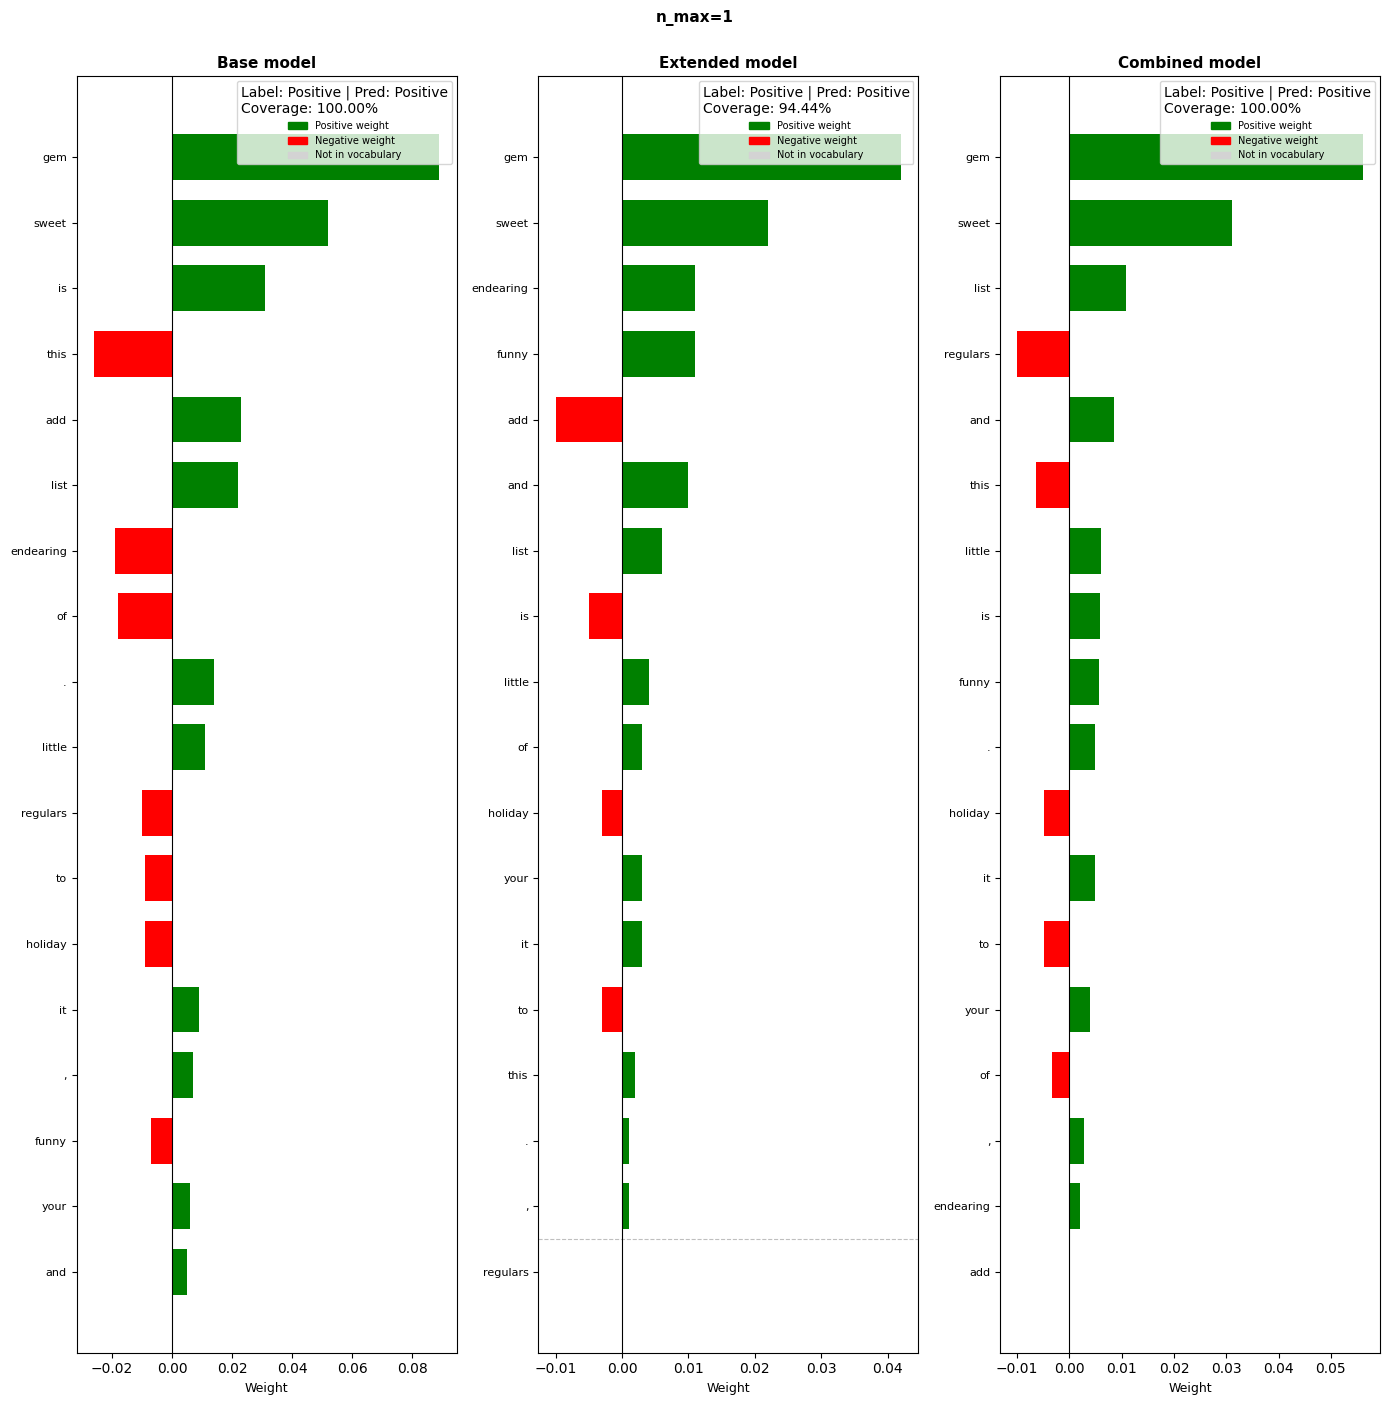

A great film in its genre , the direction , acting , most especially the casting of the film makes it even more powerful . A must see .


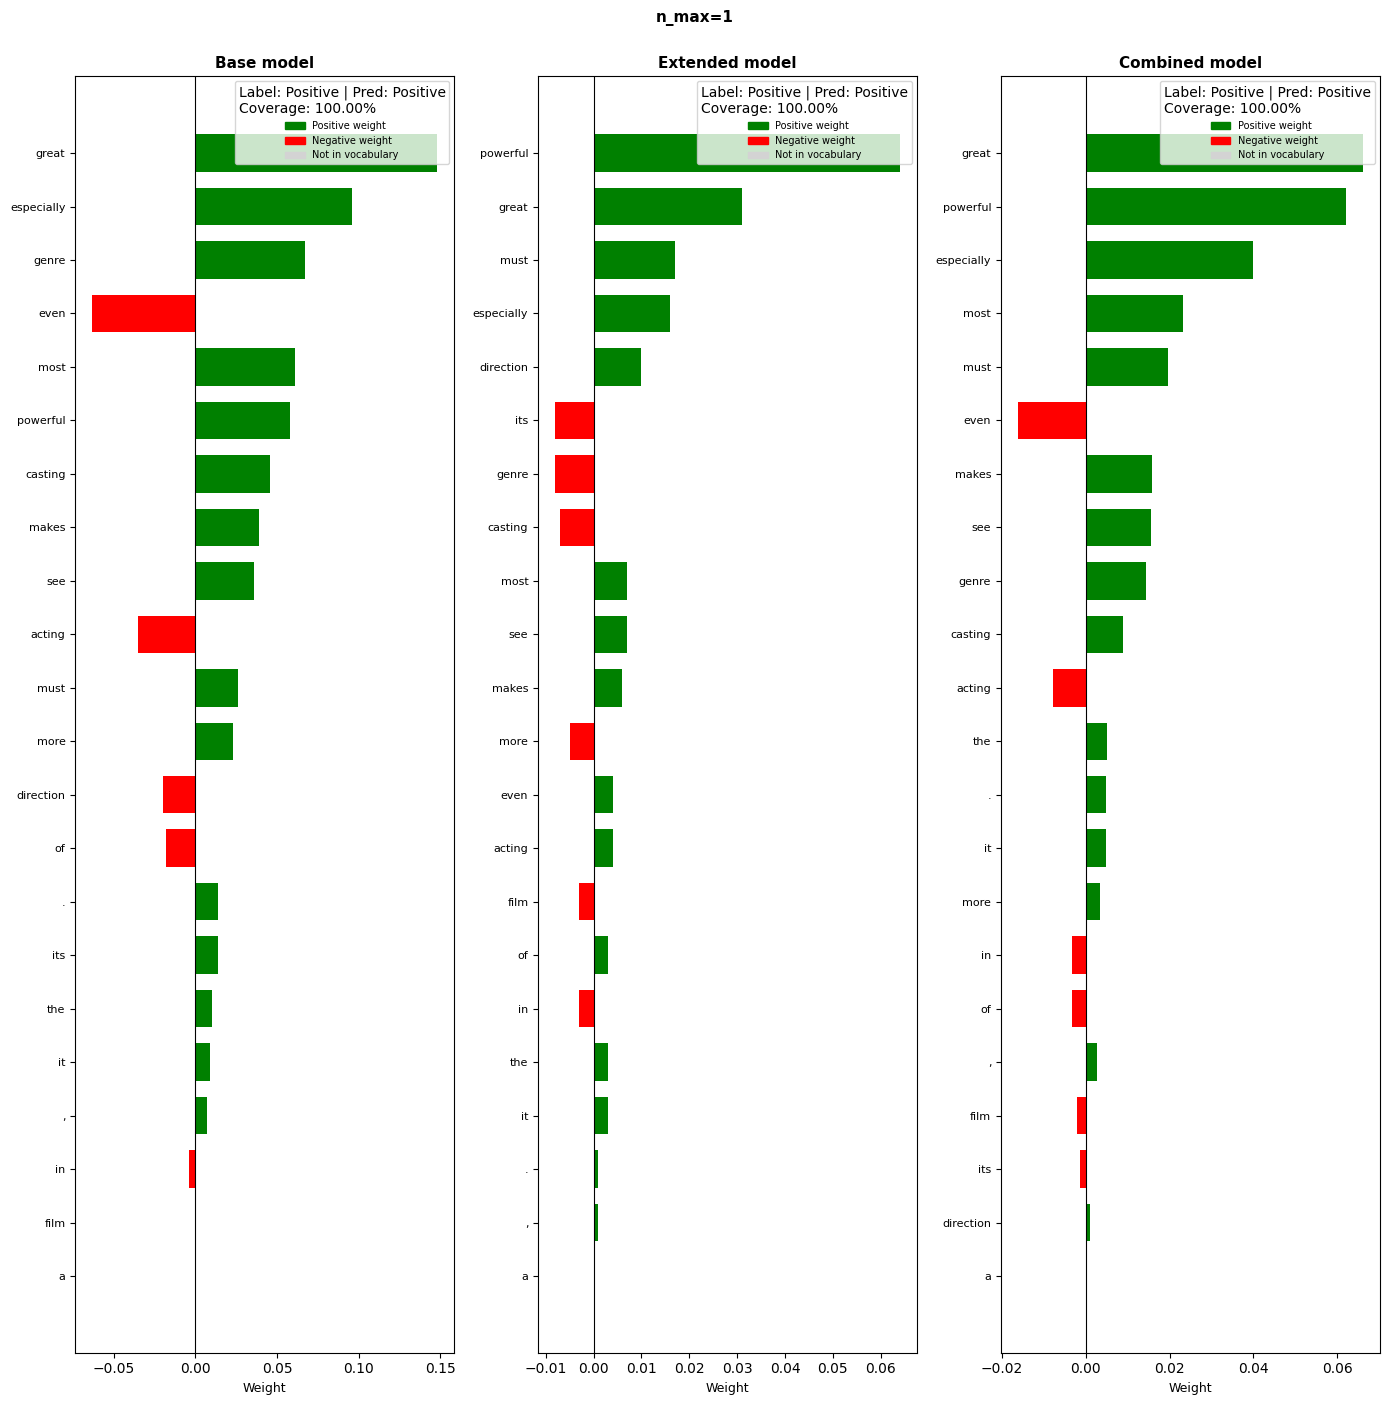

The acrobatics mixed with haunting music , make one spectacular show . The costumes are vibrant and the performances will just boggle your mind ! Simply amazing !


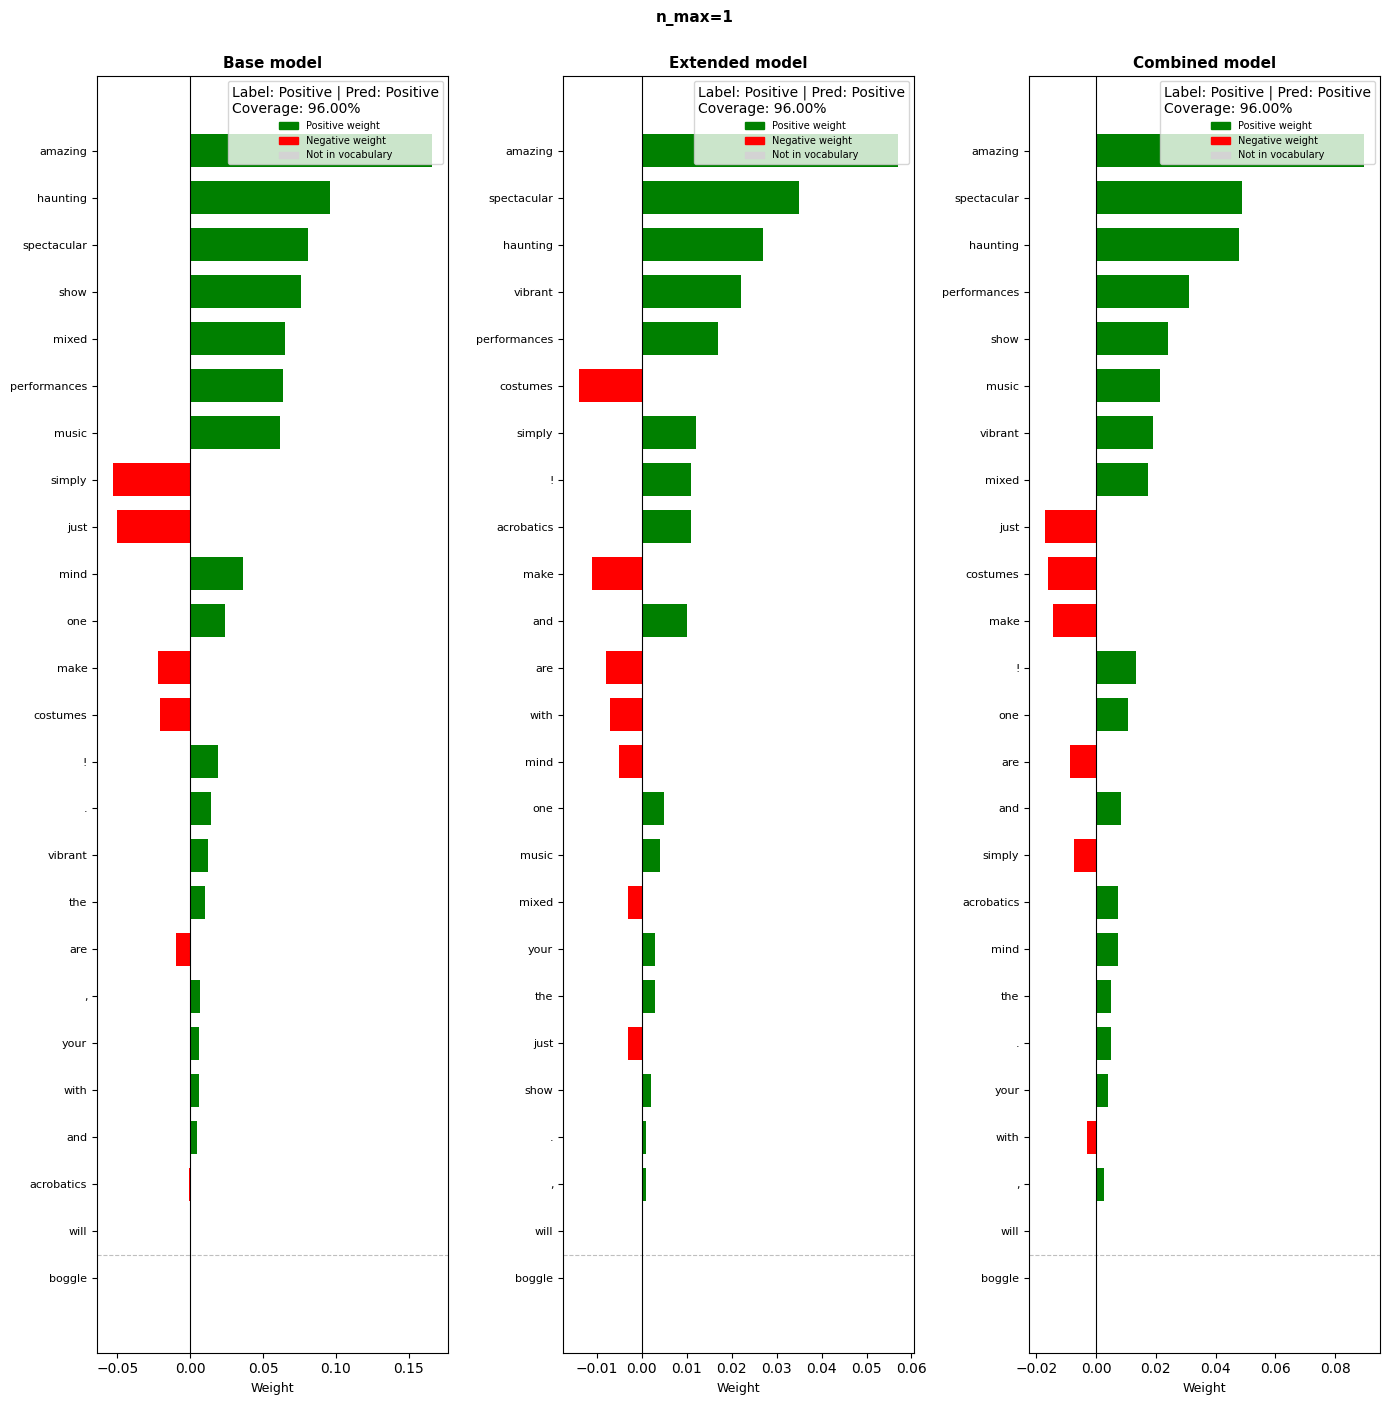

Ten minutes of people spewing gallons of pink vomit . Recurring scenes of enormous piles of dog excrement - need one say more ? ? ?


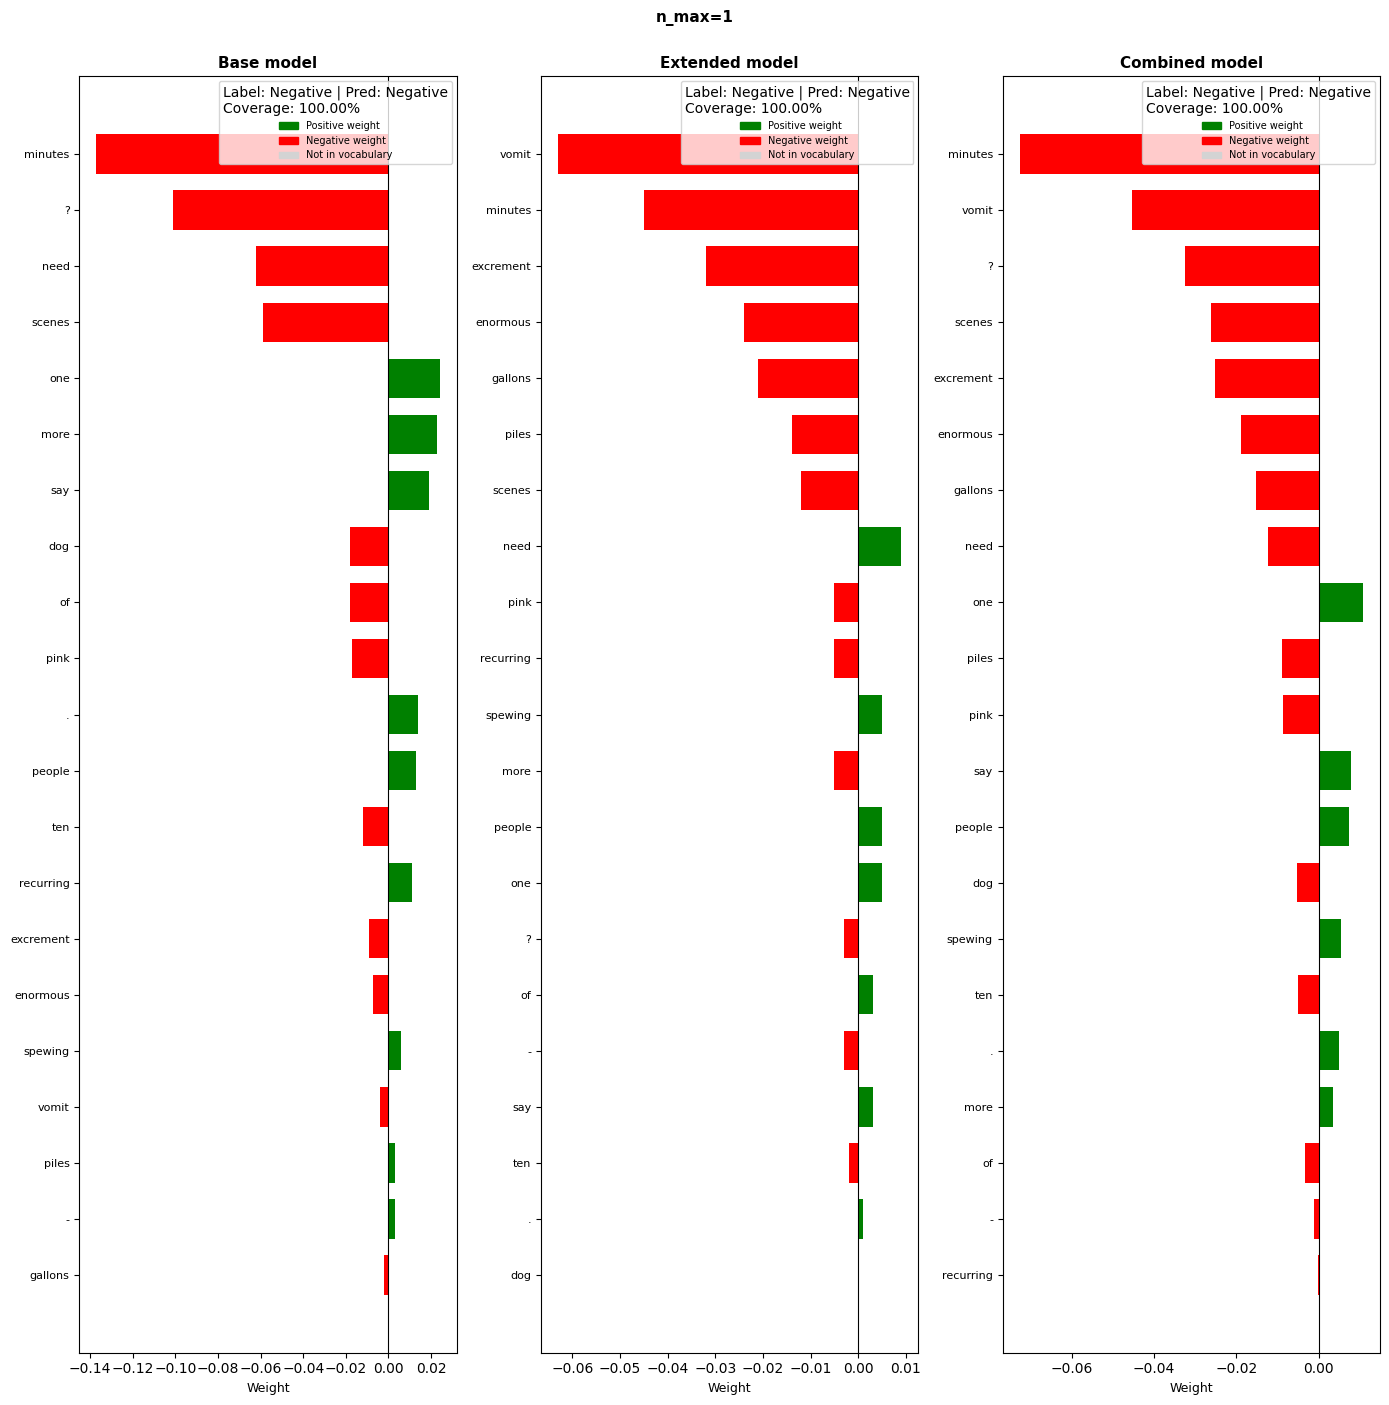


n_max=2: visualizing 4 sentences (Base | Extended | Combined)
Add this little gem to your list of holiday regulars . It is sweet , funny , and endearing


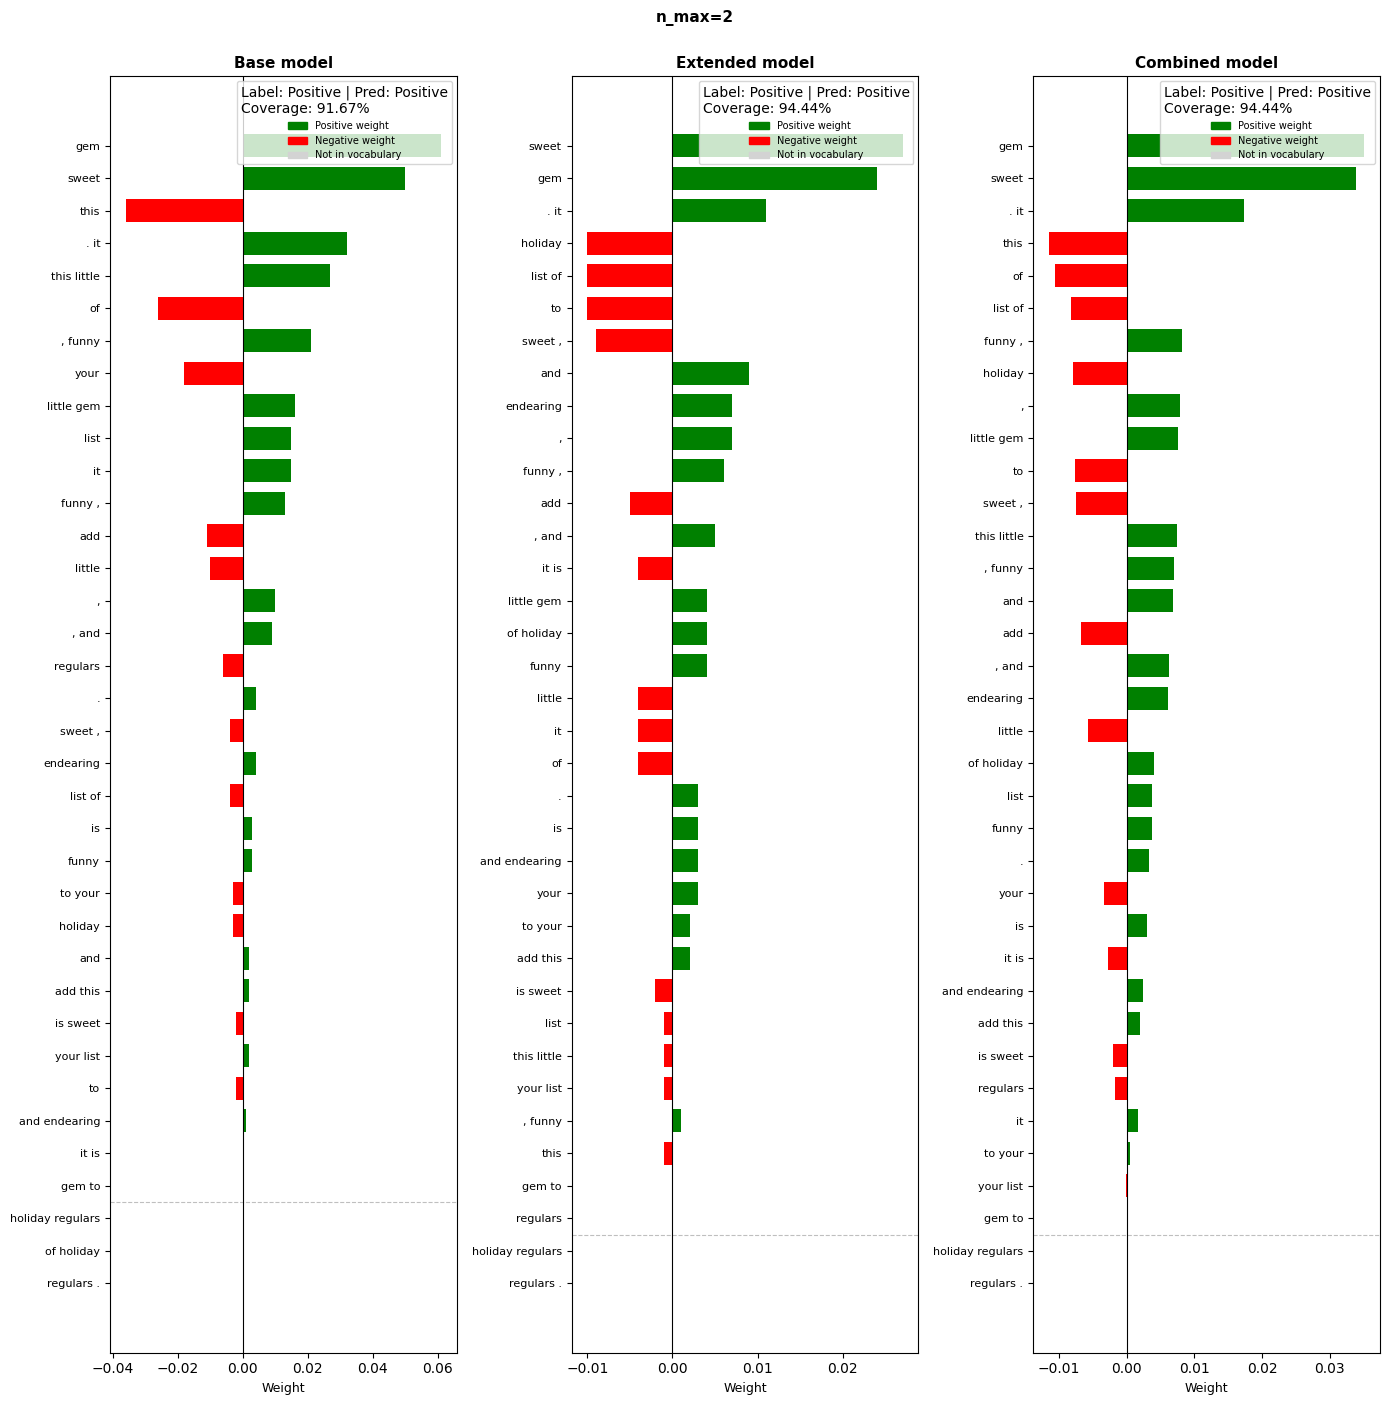

A great film in its genre , the direction , acting , most especially the casting of the film makes it even more powerful . A must see .


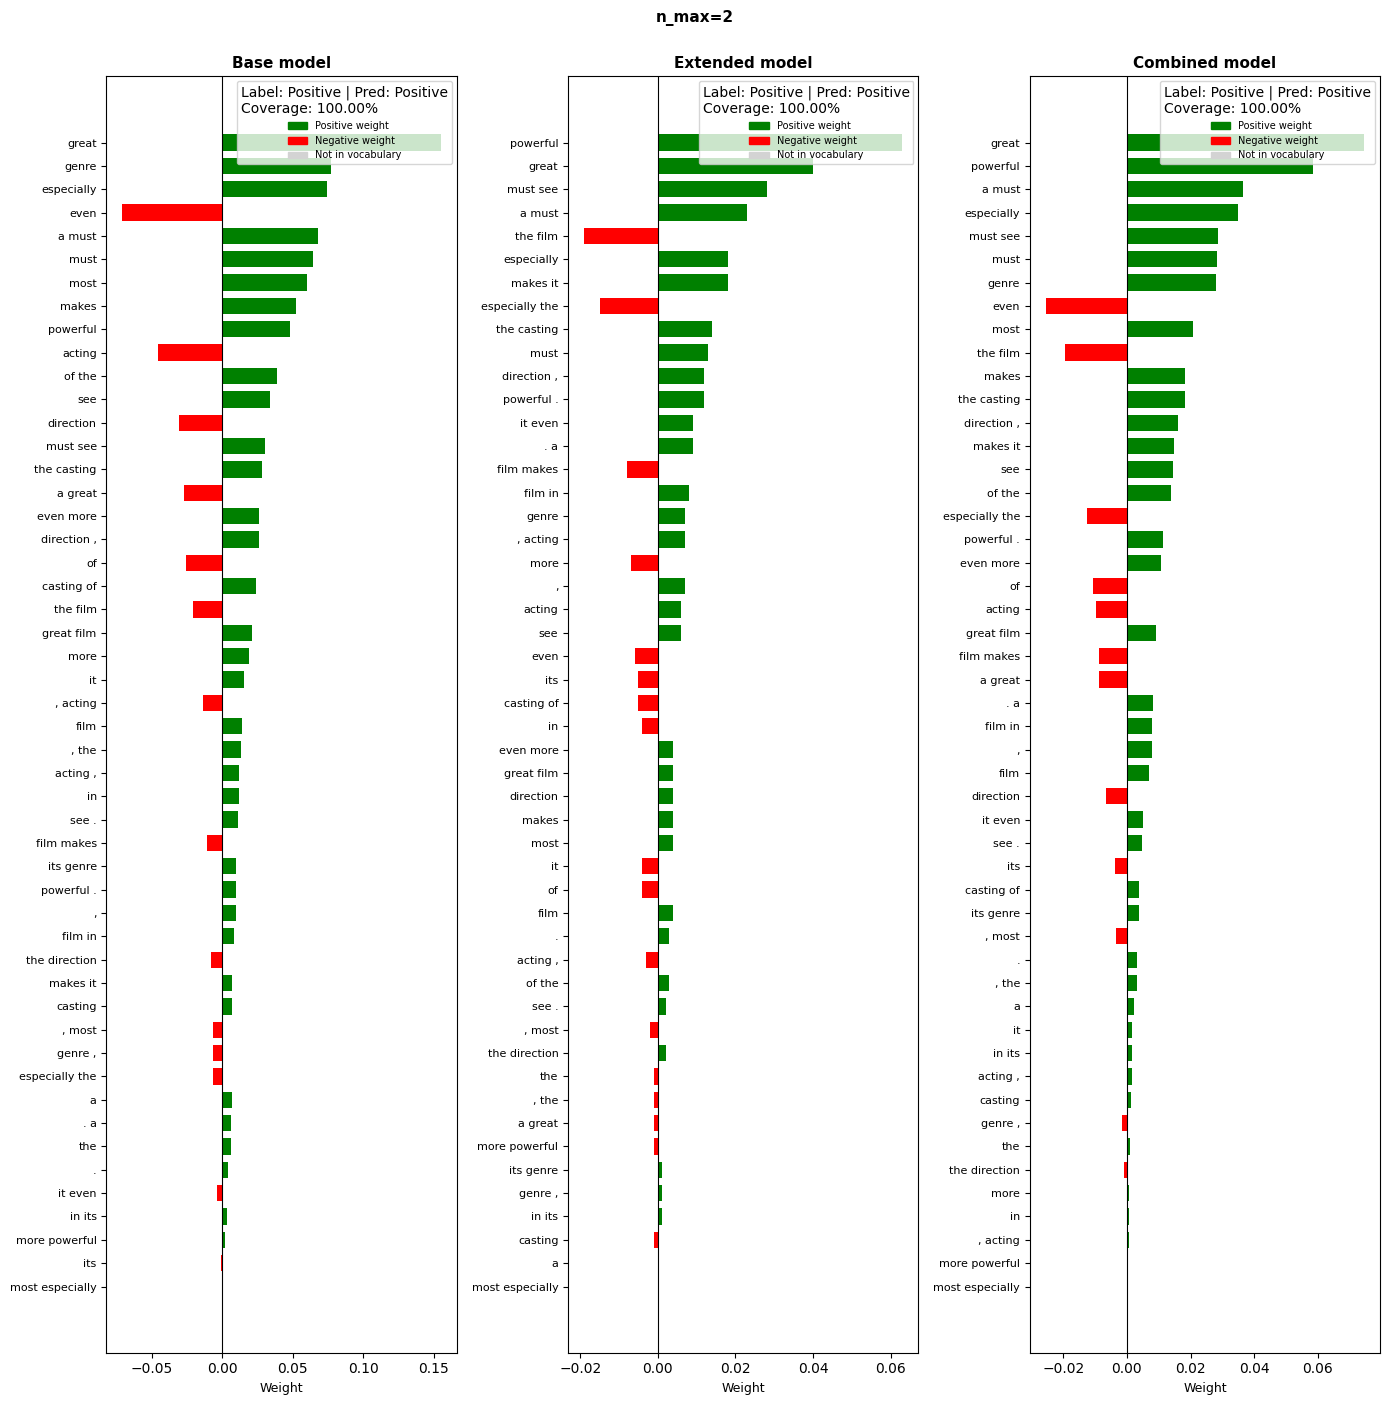

The acrobatics mixed with haunting music , make one spectacular show . The costumes are vibrant and the performances will just boggle your mind ! Simply amazing !


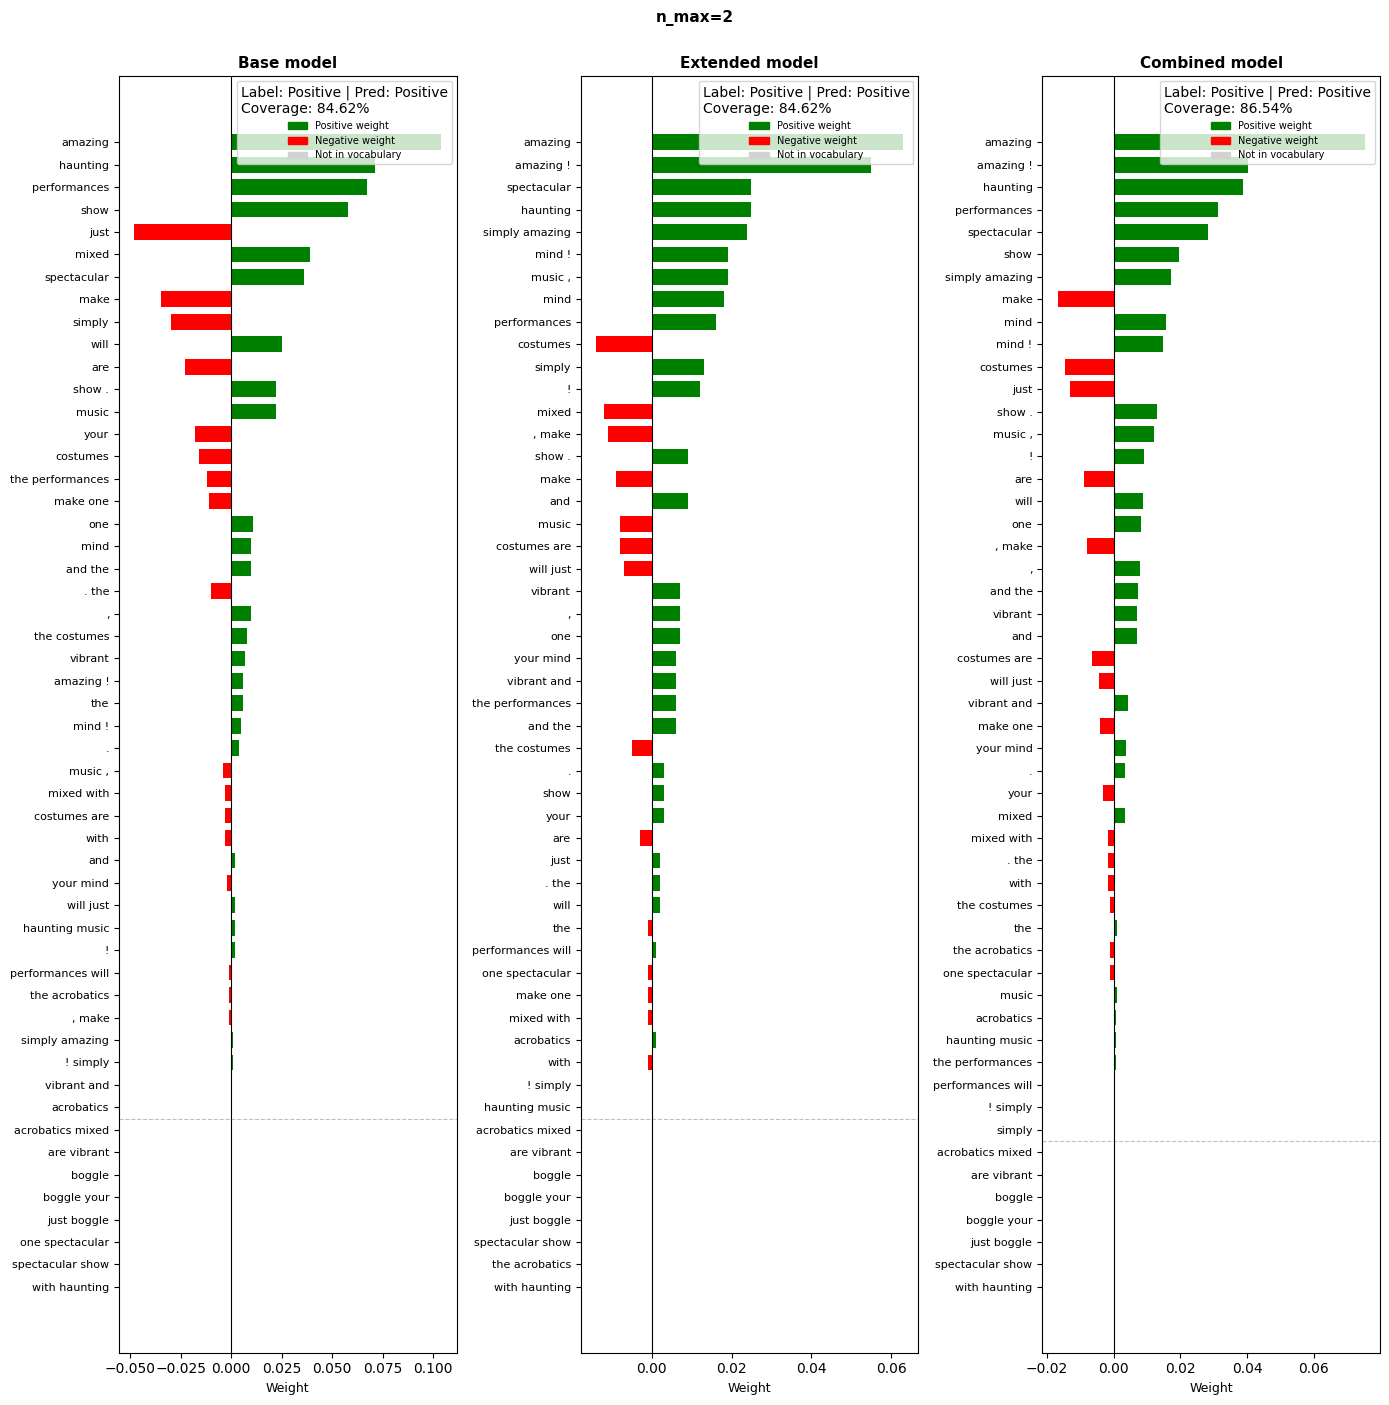

Ten minutes of people spewing gallons of pink vomit . Recurring scenes of enormous piles of dog excrement - need one say more ? ? ?


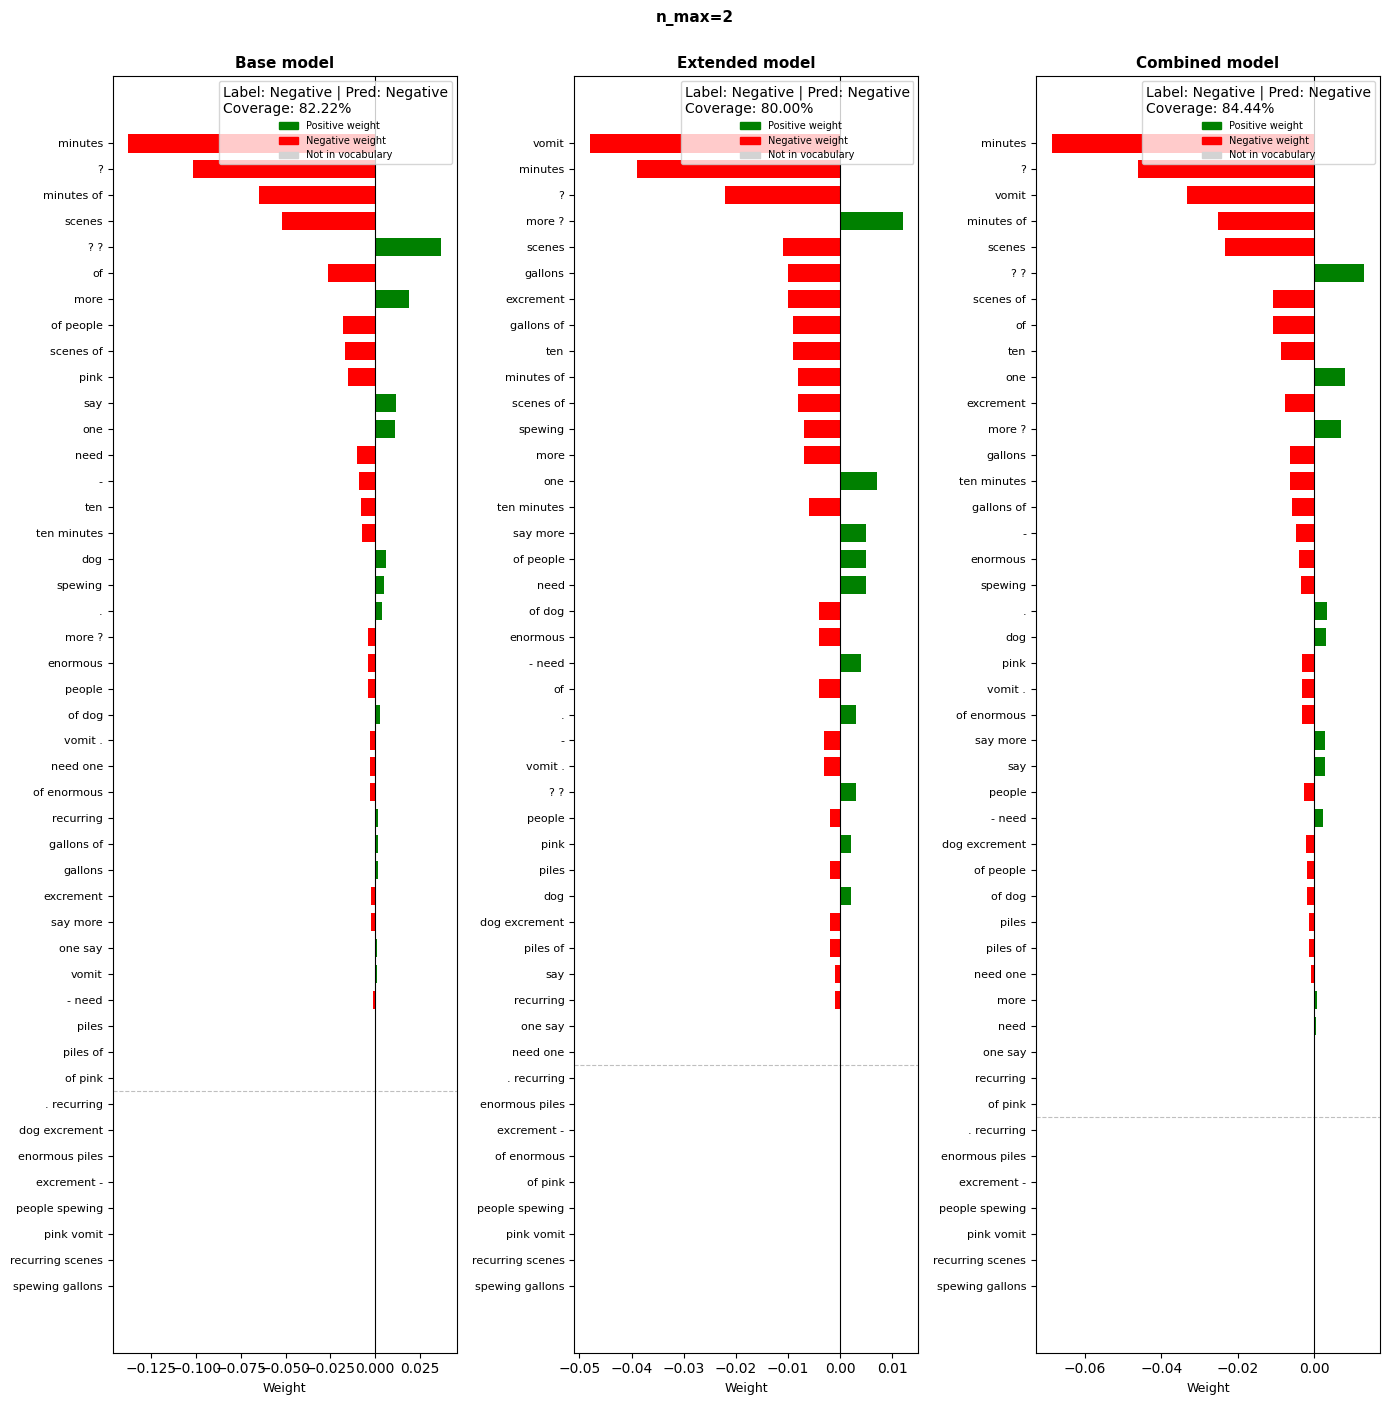


n_max=3: visualizing 4 sentences (Base | Extended | Combined)
Add this little gem to your list of holiday regulars . It is sweet , funny , and endearing


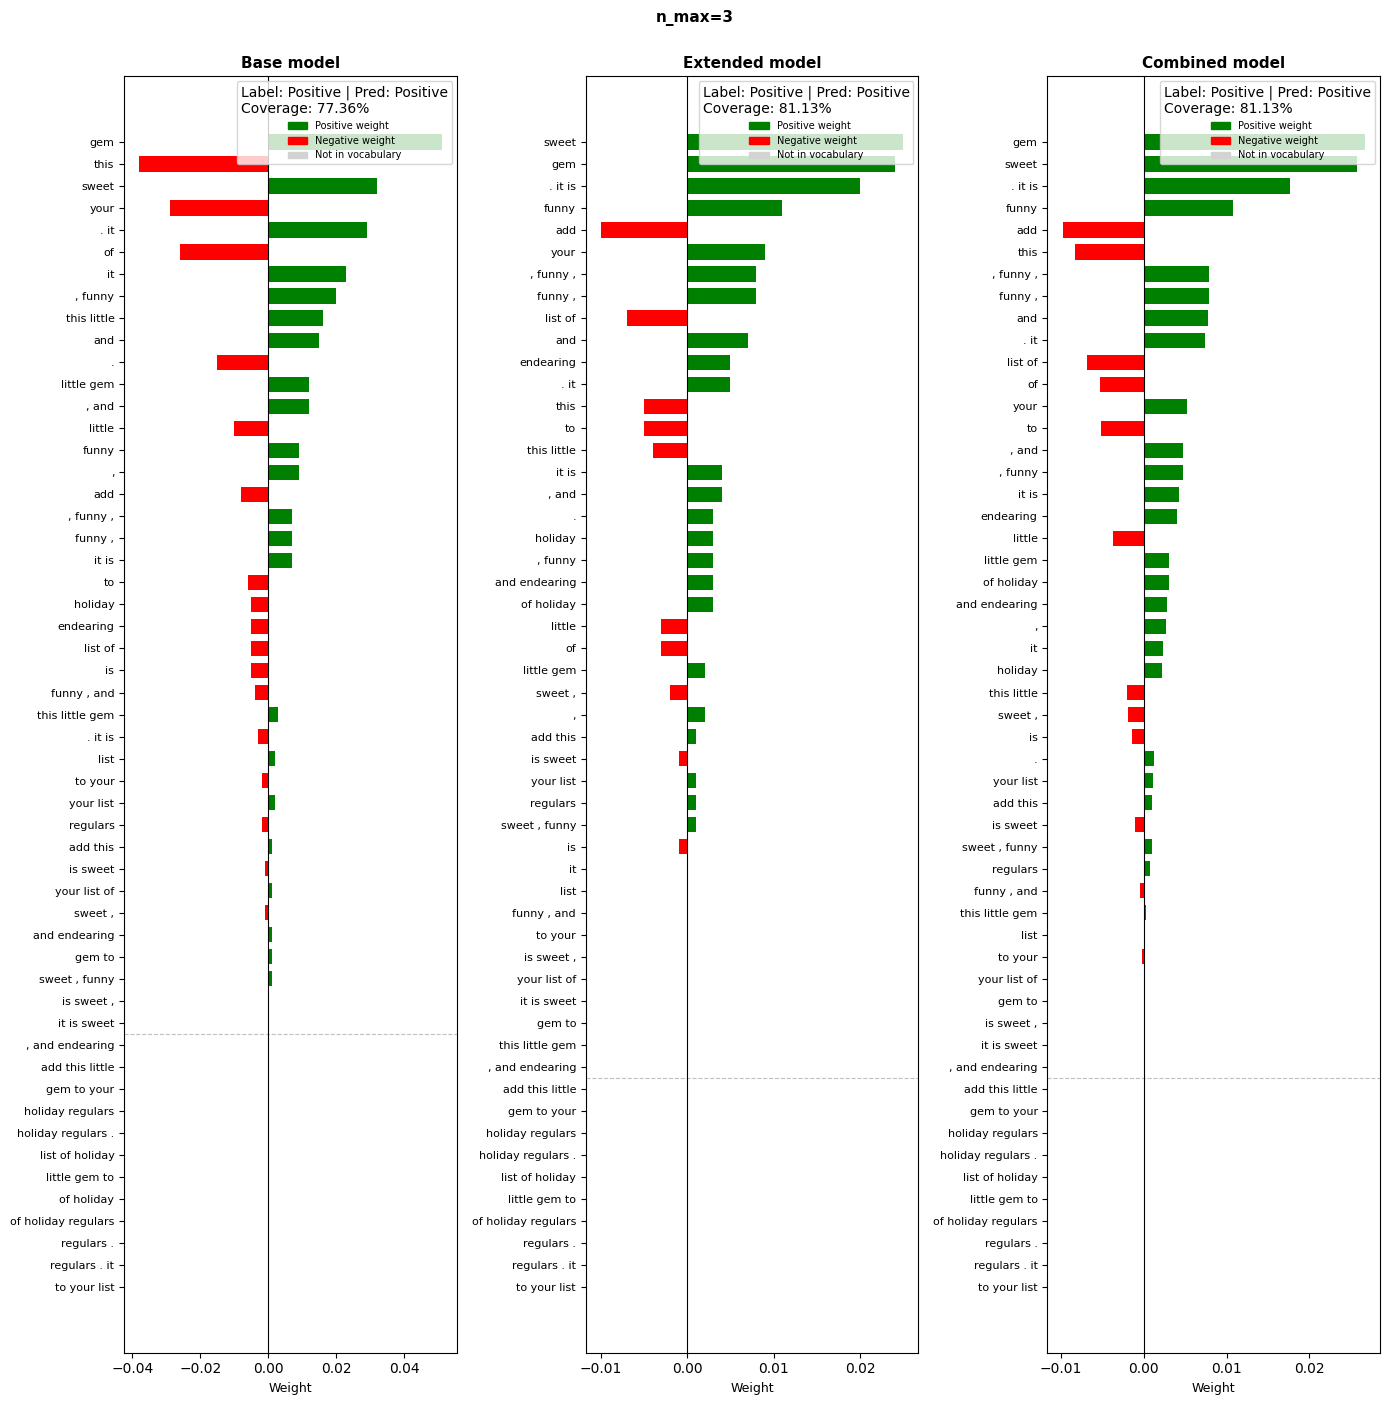

A great film in its genre , the direction , acting , most especially the casting of the film makes it even more powerful . A must see .


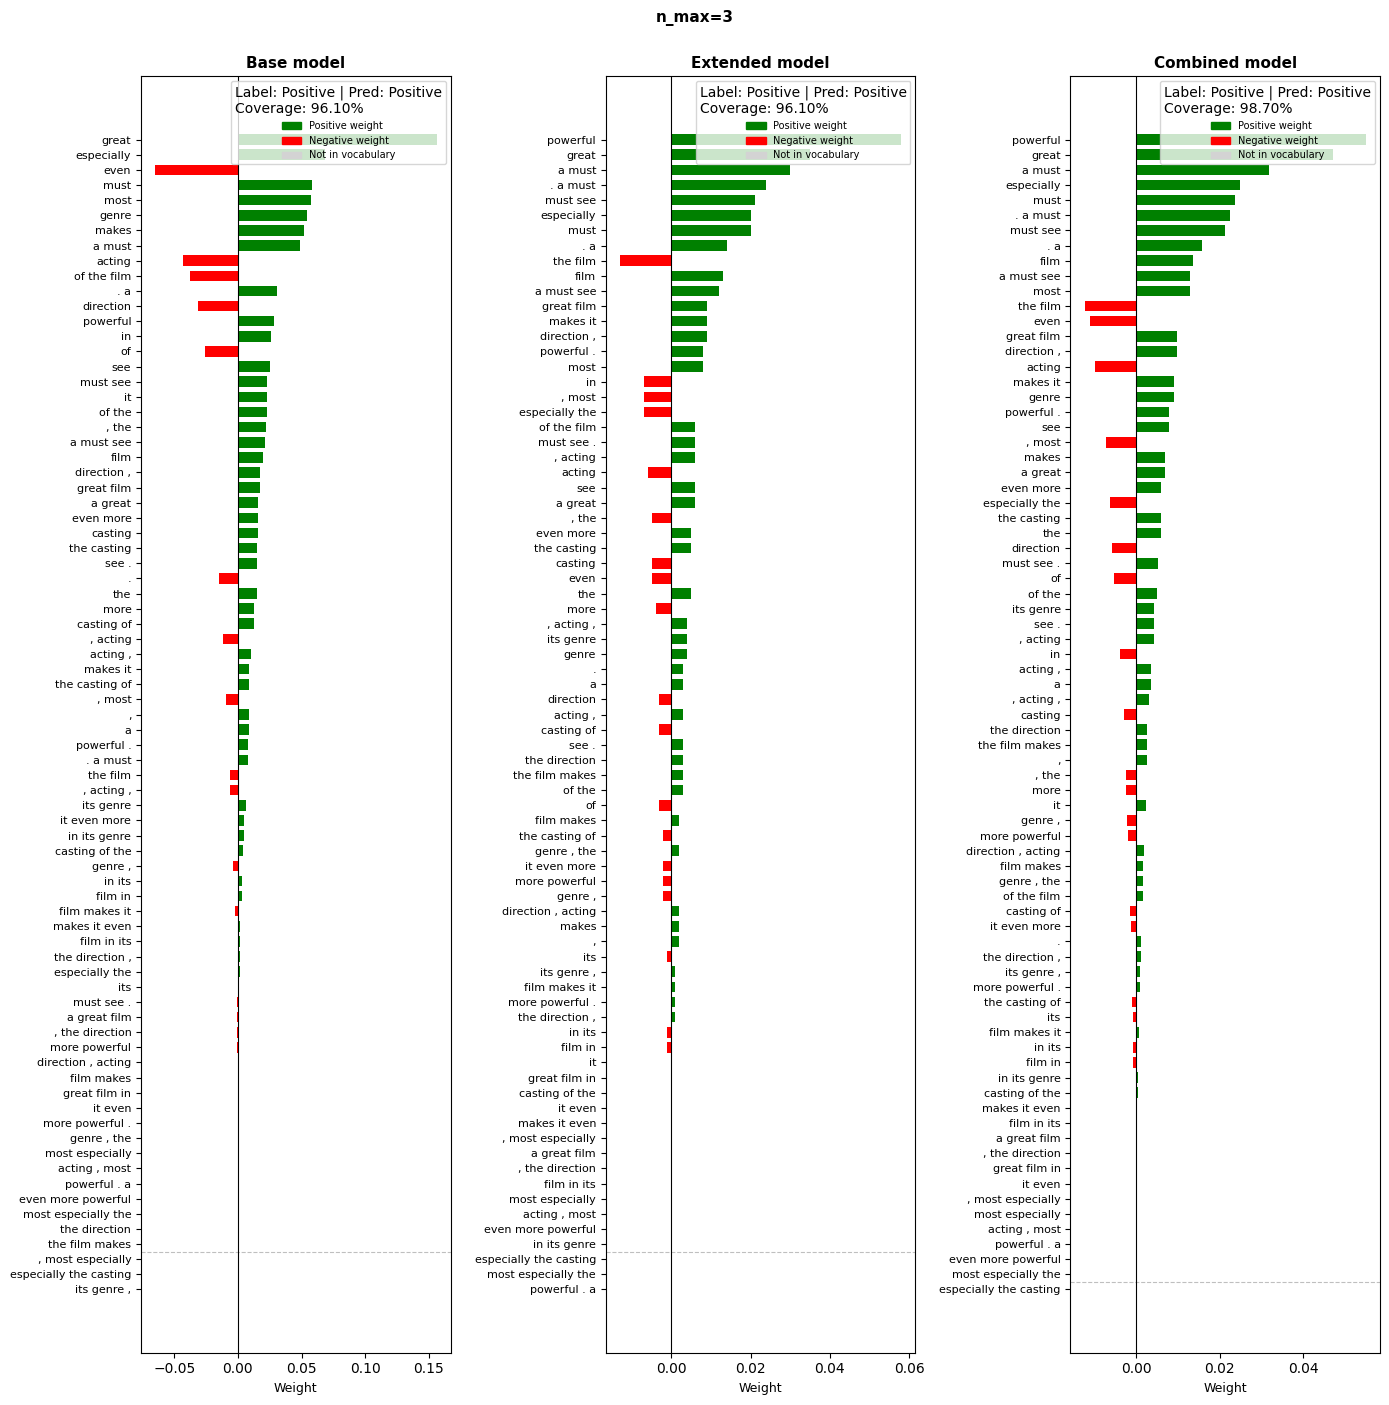

The acrobatics mixed with haunting music , make one spectacular show . The costumes are vibrant and the performances will just boggle your mind ! Simply amazing !


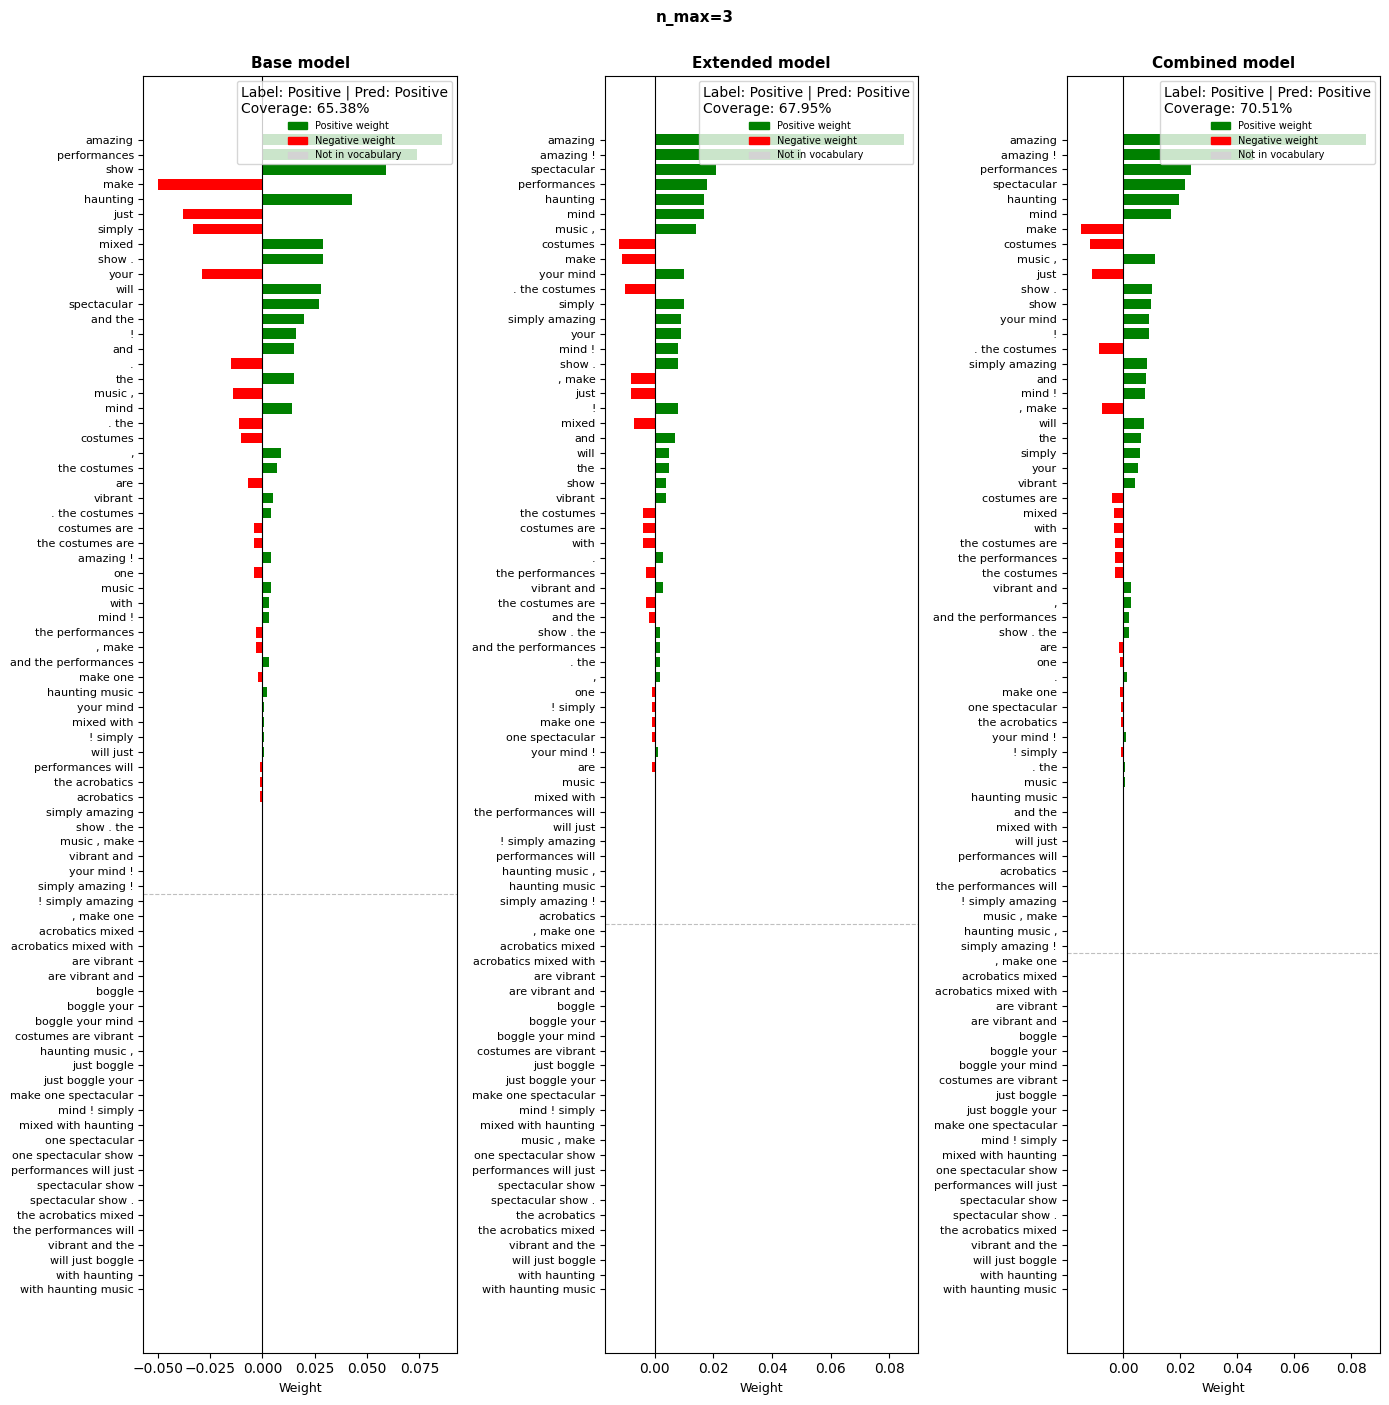

Ten minutes of people spewing gallons of pink vomit . Recurring scenes of enormous piles of dog excrement - need one say more ? ? ?


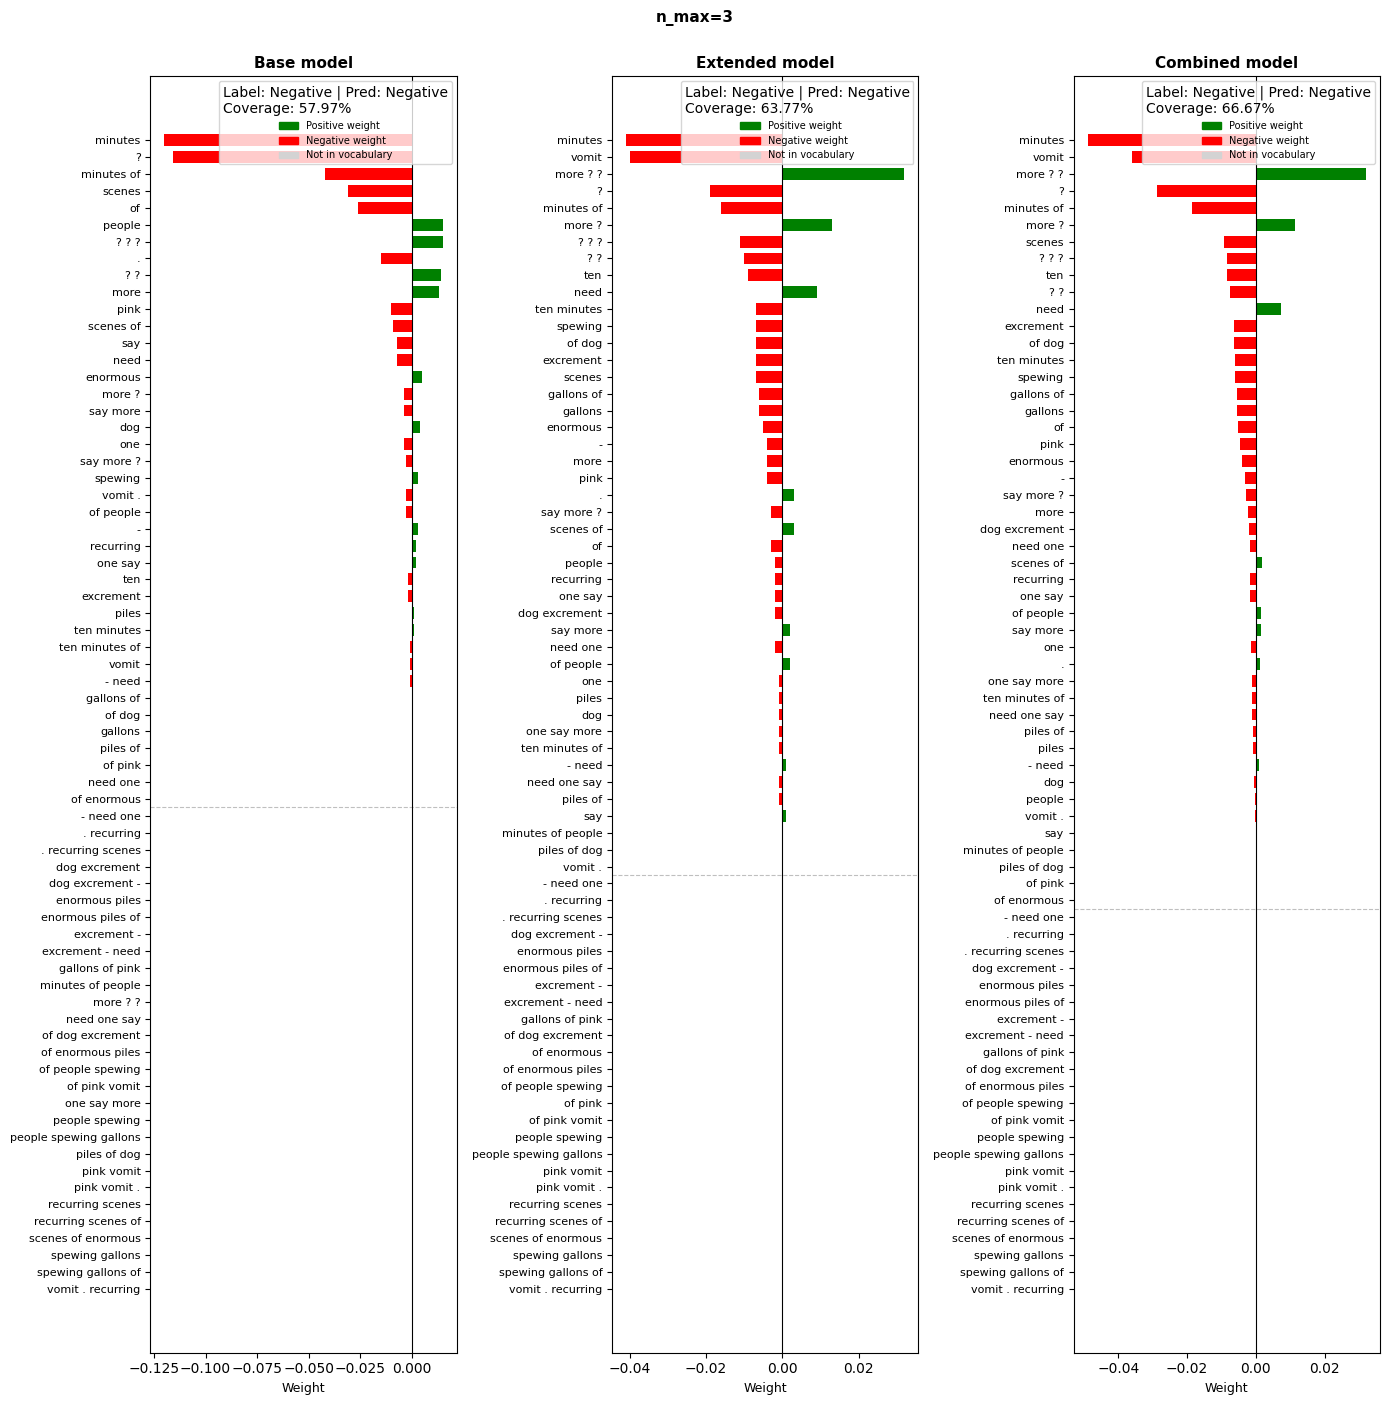

In [24]:
# same procedure as before, although now we have 3 models
def visualize_review_weights_3models(sentence, true_label,
                                      vec_b, w_b,
                                      vec_e, w_e,
                                      vec_c, w_c,
                                      n_max):
    
    token_pattern = r'\S+'

    fig, axes = plt.subplots(1, 3, figsize=(14, 14), sharey=False)
    titles  = ['Base model', 'Extended model', 'Combined model']
    configs = [(vec_b, w_b), (vec_e, w_e), (vec_c, w_c)]

    # As we did before:
    for ax, title, (vec, weights) in zip(axes, titles, configs):
        cov = visualize_review_weights(sentence, true_label, vec, weights, n_max, ax=ax)
        ax.set_title(f"{title}", fontsize=11, fontweight='bold')

    fig.suptitle(rf'n_max={n_max}', fontsize=11, fontweight='bold', y=1)
    fig.tight_layout()
    plt.show()


def run_visualization_all(n_max_idx, n_sentences=4):
    n_max = n_max_list[n_max_idx]

    # models
    vec_b, w_b = best_vectorizers[n_max_idx],          best_weights_per_n[n_max_idx]
    vec_e, w_e = best_vectorizers_new[n_max_idx],      best_weights_per_n_new[n_max_idx]
    vec_c, w_c = best_vectorizers_combined[n_max_idx], best_weights_combined[n_max_idx]

    # Sentences with 15 to 30 words
    sentences_under_study, labels_under_study = [], []
    for i, text in enumerate(test_texts):
        if 15 <= len(text.split()) <= 30:
            sentences_under_study.append(text)
            labels_under_study.append(test_labels[i])
        if len(sentences_under_study) == n_sentences:
            break

    print(f"\nn_max={n_max}: visualizing {len(sentences_under_study)} sentences (Base | Extended | Combined)")

    for sentence, label in zip(sentences_under_study, labels_under_study):
        print(sentence)
        visualize_review_weights_3models(
            sentence, label,
            vec_b, w_b,
            vec_e, w_e,
            vec_c, w_c,
            n_max
        )

for idx in range(len(n_max_list)):
    run_visualization_all(idx, n_sentences=4)